In [16]:
#Check for NaNs
df.isna().sum()

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


Age                            0
Gender                         0
Country                        0
Ethnicity                      0
Family_History                 0
Radiation_Exposure             0
Iodine_Deficiency              0
Smoking                        0
Obesity                        0
Diabetes                       0
TSH_Level                      0
T3_Level                       0
T4_Level                       0
Nodule_Size                    0
Thyroid_Cancer_Risk            0
Diagnosis                      0
Gender_binary                  0
Family_History_binary          0
Radiation_Exposure_binary      0
Iodine_Deficiency_binary       0
Smoking_binary                 0
Obesity_binary                 0
Diabetes_binary                0
Thyroid_Cancer_Risk_encoded    0
dtype: int64

In [ ]:
#Check for duplicated rows
print(f"There are {df.duplicated().sum()} duplicated rows.")

In [19]:
#Check data types
df.dtypes

Patient_ID               int64
Age                      int64
Gender                  object
Country                 object
Ethnicity               object
Family_History          object
Radiation_Exposure      object
Iodine_Deficiency       object
Smoking                 object
Obesity                 object
Diabetes                object
TSH_Level              float64
T3_Level               float64
T4_Level               float64
Nodule_Size            float64
Thyroid_Cancer_Risk     object
Diagnosis               object
dtype: object

## Check for Class Imbalances in Target

In [8]:
df['Diagnosis'].value_counts(normalize=True)

Diagnosis
Benign       0.767292
Malignant    0.232708
Name: proportion, dtype: float64

77% of the targets are benign and 23% are malignant. This imbalance will skew results of a machine learning algorithm. Flipping a coin would likely be a better machine learning algorithm with this imbalance issue.

Downsampling the majority class should help when finding relationships between features and the target during EDA, but will cause a loss of good data. So, during the training section it will be better to upsample the minority class, probably using SMOTE-TOMEKS


# Feature Relevence

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## Check for Linear Dependencies

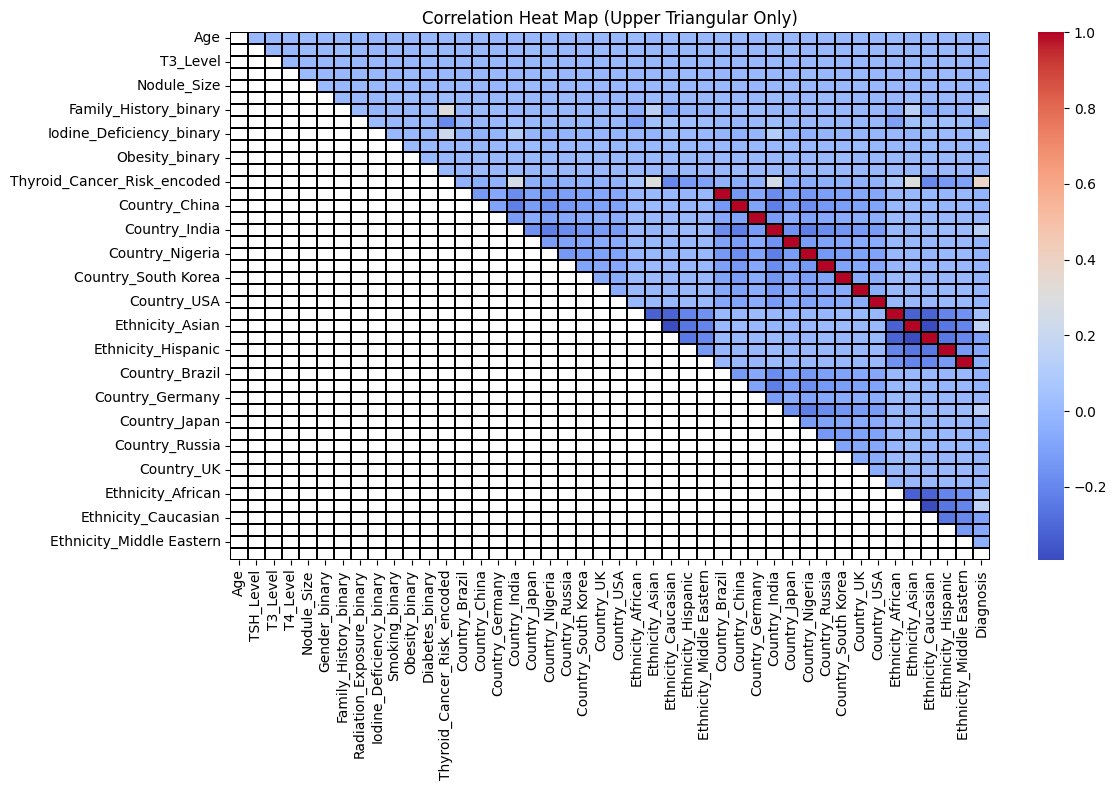

In [182]:
df_ = pd.concat([X_train,y_train],axis=1)
corr_mat = df_.corr(numeric_only=True)
mask = np.tril(np.ones_like(corr_mat))

plt.figure(figsize=(12,8))
sns.heatmap(corr_mat,mask=mask,cmap='coolwarm',annot=False,fmt='.2f',linewidths=0.25,linecolor='k')
plt.title('Correlation Heat Map (Upper Triangular Only)')
plt.tight_layout()

Linear Dependencies:

**Definitely Correlates:** Thyroid_Cancer_Risk, Iodine_Deficiency, Obesity, Radiation_Exposure, Family_History

**Potentially Correlates:** Ethnicity, Being from India

**Probably Does Not Correlate:** Age (as an integer), TSH_Level, T3_Level, T4_Level, Nodule_Size, Country, Smoking

The fact that India correlates to diagnosis and other countries do not is interesting, but suspicious. If India is over-represented in the dataset then it will have a higher incidence of malignant even if the ratio of malignant:benign is the same as the other countries.

### **Actionable Insights:** 

1. Check the ratio of malignant to benign for countries and compare India to the others.
2. Check the ratios of high, medium, and low counts for Thyroid_Cancer_Risk among countries.
3. Check the ratio of Family_History among countries.

If India has the same ratio as other countries we can discard the country feature. If not perform steps 2 and 3. If steps 2 and 3 are significantly different from steps 1, then it is likely that just being from India is a risk.

## Check for Non-Linear Dependencies

In [8]:
from sklearn.feature_selection import mutual_info_classif

In [184]:
data = df.copy()
target = data.pop('Diagnosis')

ordinal_feats = ['Thyroid_Cancer_Risk',]
onehot_feats = ['Country','Ethnicity',]
data,bins = encoder(data, ordinal_feats, onehot_feats,return_binaries=True)

data = data.select_dtypes(include='number')

mi_scores = mutual_info_classif(data,target)

mi_df = pd.DataFrame({'Feature': data.columns, 'MI Score': mi_scores})
print(mi_df.sort_values(by='MI Score', ascending=False))

                        Feature  MI Score
12  Thyroid_Cancer_Risk_encoded  0.098140
7     Radiation_Exposure_binary  0.032804
5                 Gender_binary  0.027013
6         Family_History_binary  0.017219
25          Ethnicity_Caucasian  0.013313
24              Ethnicity_Asian  0.012574
16                Country_India  0.009379
8      Iodine_Deficiency_binary  0.009336
10               Obesity_binary  0.007926
9                Smoking_binary  0.004248
26           Ethnicity_Hispanic  0.003990
11              Diabetes_binary  0.003653
23            Ethnicity_African  0.003138
18              Country_Nigeria  0.002551
27     Ethnicity_Middle Eastern  0.001545
15              Country_Germany  0.001513
14                Country_China  0.001241
3                      T4_Level  0.001093
21                   Country_UK  0.000982
4                   Nodule_Size  0.000676
2                      T3_Level  0.000650
0                           Age  0.000586
20          Country_South Korea  0

From the Mutual Info we can see that the highest score is **Thyroid_Cancer_Risk** and **Radiation_Exposure** as one would expect. 

**Gender** and **Family_History** also seem to be slightly related to diagnosis.

Most of the **Ethnicity** and **Country** one hot encoded features do not show much in the way of predictive power, but it could be releaved with enough coaxing. I noticed in several other people's code on this data set that they discarded these features right away, most likely in an attempt to create an more equitable learning algorithm. But typically medical professionals consider these things because of genetic and environmental factors. I will keep them in for now.

Serium levels **T4_Level** and **T3_Level** do not seem to hold any predictive power, but I need to look into how these could possibly effect the incidence of malignant thyroid tumors. I will try to do some feature engineering on them.

**Nodule_Size** does not appear to be linked to the diagnosis, but it may be related to T4 and T3 levels.

**Age** does not really have much predictive power, but it is an integer. I think that binning age into values will be useful.

**Diabetes**, **Smoking**, and **Obesity** do not appear to have any predictive power.

### Actionable Insights:

1. Bin **Age** into groups.
2. Literature review to research how **T4_Level**, **T3_Level**, **Nodule_Size**, and **TSH_Level** affect thyroid cancer.
3. Perform feature engineering on **T4_Level**, **T3_Level**, **Nodule_Size**, and **TSH_Level**.
4. Do steps 1-3 in the *Check for Linear Dependencies* section. 

# Exploratory Data Analysis

## Check ratio of malignant to benign for each country

In [100]:
country_diagnosis_counts = df.groupby('Country')['Diagnosis'].value_counts().unstack()
country_diagnosis_counts['Malignant']/country_diagnosis_counts['Benign']*100

Country
Brazil         26.449746
China          26.495253
Germany        26.582734
India          49.004208
Japan          25.985958
Nigeria        26.628580
Russia         26.843359
South Korea    25.946810
UK             26.434597
USA            25.109610
dtype: float64

The ratio of malignant/benign for India is nearly double those of the other countries. I will need to check other highly correlated features for each country to see if this difference is due to the presence of a feature in India data (and therefore duplicated in the country data) or if it is unique to the India country feature.

In [107]:
country_thyroid_counts = df.groupby('Country')['Thyroid_Cancer_Risk'].value_counts().unstack()
country_thyroid_counts['Total'] = country_thyroid_counts['High']+country_thyroid_counts['Medium']+country_thyroid_counts['Low']

print(country_thyroid_counts['High']/country_thyroid_counts['Total']*100)
print(country_thyroid_counts['Medium']/country_thyroid_counts['Total']*100)
print(country_thyroid_counts['Low']/country_thyroid_counts['Total']*100)

Country
Brazil         10.778499
China          10.848083
Germany        10.580657
India          32.861916
Japan          10.061066
Nigeria        10.517576
Russia         10.452176
South Korea    10.497828
UK             10.402180
USA            10.286039
dtype: float64
Country
Brazil         36.197637
China          35.552567
Germany        35.388842
India          26.858998
Japan          35.940001
Nigeria        35.982831
Russia         35.728037
South Korea    36.424992
UK             35.068596
USA            35.906422
dtype: float64
Country
Brazil         53.023864
China          53.599350
Germany        54.030501
India          40.279085
Japan          53.998933
Nigeria        53.499593
Russia         53.819787
South Korea    53.077180
UK             54.529224
USA            53.807539
dtype: float64


In [113]:
country_family_counts = df.groupby('Country')['Family_History'].value_counts().unstack()
country_family_counts['Total'] = country_family_counts['No']+country_family_counts['Yes']
print(country_family_counts['No']/country_family_counts['Total']*100)
print(country_family_counts['Yes']/country_family_counts['Total']*100)

Country
Brazil         70.228366
China          69.563450
Germany        69.669414
India          69.881871
Japan          70.445248
Nigeria        70.082712
Russia         69.962906
South Korea    70.263949
UK             69.949258
USA            70.287933
dtype: float64
Country
Brazil         29.771634
China          30.436550
Germany        30.330586
India          30.118129
Japan          29.554752
Nigeria        29.917288
Russia         30.037094
South Korea    29.736051
UK             30.050742
USA            29.712067
dtype: float64


Because **Thyroid_Cancer_Risk** High value is nearly 3 times higher in India than it is in other countries and about the same for Medium and Low. I think that the **Country** data is duplicating information from **Thyroid_Cancer_Risk** and other features.

### Actionable Insights:
1. Drop the **Country** features

## Bin Ages into groups

According to the American Cancer Society, the majority of cancer cases occur between the ages of 30 and 60. I will put the data into two bins (1) between 30 and 60 (2) not between 30 and 60

https://www.cancer.org/cancer/types/thyroid-cancer/causes-risks-prevention/risk-factors.html

In [23]:
age_binned = df[['Age','Diagnosis']]
age_binned['Age_binned_binary'] = age_binned['Age'].apply(lambda x:1 if (x >= 30) & (x <= 60) else 0)
age_binned['Age_binned_3'] = pd.cut(age_binned['Age'],bins=[0,29,61,np.inf],labels=['Low','Med','High'])
age_binned['Age_binned_10'] = pd.cut(
    age_binned['Age'], 
    bins=list(range(0,101,10)),
    labels=[f"{i*10}-{(i+1)*10}" for i in range(0,11)].append('100+')
)
age_binned

/tmp/ipykernel_35/2977020785.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  age_binned['Age_binned_binary'] = age_binned['Age'].apply(lambda x:1 if (x >= 30) & (x <= 60) else 0)
/tmp/ipykernel_35/2977020785.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  age_binned['Age_binned_3'] = pd.cut(age_binned['Age'],bins=[0,29,61,np.inf],labels=['Low','Med','High'])
/tmp/ipykernel_35/2977020785.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[r

,Age,Diagnosis,Age_binned_binary,Age_binned_3,Age_binned_10
0,66,Benign,0,High,"(60, 70]"
1,29,Benign,0,Low,"(20, 30]"
2,86,Benign,0,High,"(80, 90]"
3,75,Benign,0,High,"(70, 80]"
4,35,Benign,1,Med,"(30, 40]"
...,...,...,...,...,...
212686,58,Benign,1,Med,"(50, 60]"
212687,89,Benign,0,High,"(80, 90]"
212688,72,Benign,0,High,"(70, 80]"
212689,85,Benign,0,High,"(80, 90]"


<Axes: xlabel='Age_binned_binary'>

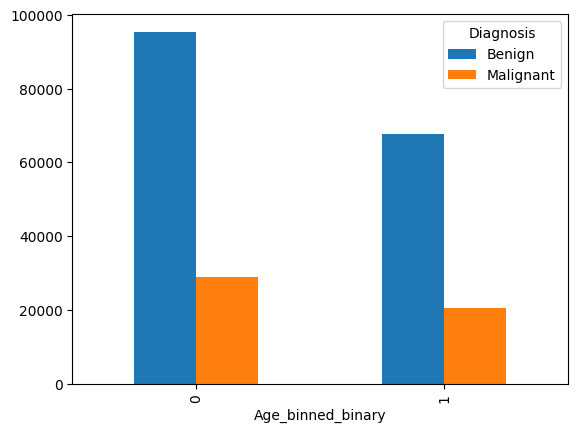

In [25]:
age_binned.groupby(['Age_binned_binary','Diagnosis']).size().unstack().plot(kind='bar')

/tmp/ipykernel_35/849941692.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_binned.groupby(['Age_binned_3','Diagnosis']).size().unstack().plot(kind='bar')


<Axes: xlabel='Age_binned_3'>

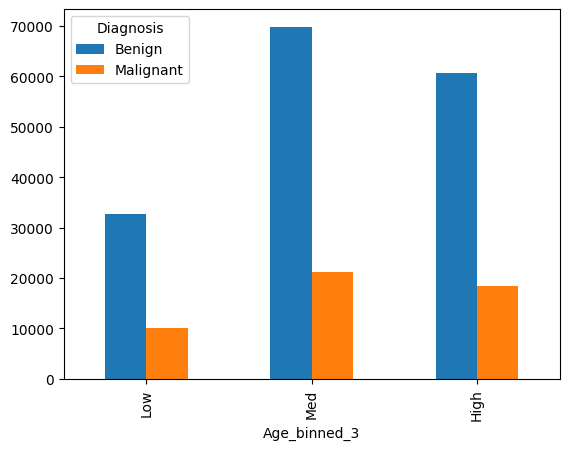

In [26]:
age_binned.groupby(['Age_binned_3','Diagnosis']).size().unstack().plot(kind='bar')

/tmp/ipykernel_35/2089920575.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_binned.groupby(['Age_binned_10','Diagnosis']).size().unstack().plot(kind='bar')


<Axes: xlabel='Age_binned_10'>

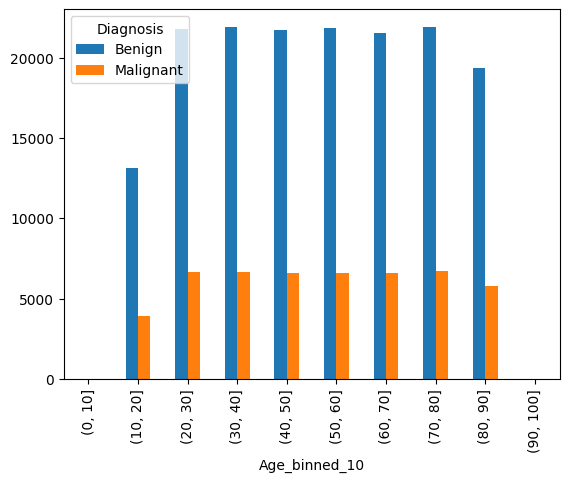

In [28]:
age_binned.groupby(['Age_binned_10','Diagnosis']).size().unstack().plot(kind='bar')

/tmp/ipykernel_35/4275995063.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  age_binned['Age_quartiles'] = pd.qcut(df['Age'],q=4)
/tmp/ipykernel_35/4275995063.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_binned.groupby(['Age_quartiles','Diagnosis']).size().unstack().plot(kind='bar')


<Axes: xlabel='Age_quartiles'>

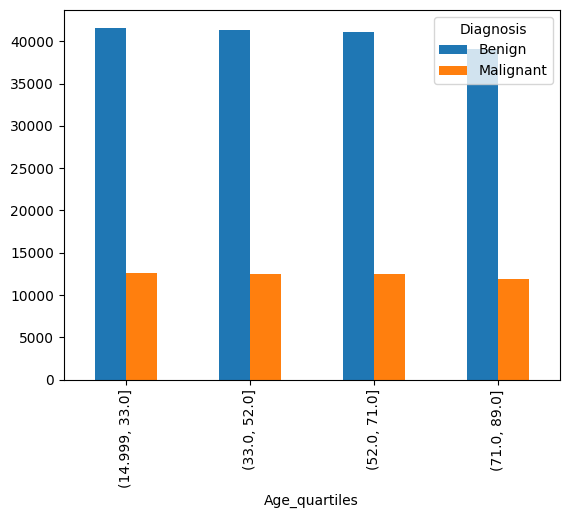

In [36]:
age_binned['Age_quartiles'] = pd.qcut(df['Age'],q=4)
age_binned.groupby(['Age_quartiles','Diagnosis']).size().unstack().plot(kind='bar')

/tmp/ipykernel_35/2378679984.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  age_binned['Age_binned_20'] = pd.qcut(df['Age'],q=11)
/tmp/ipykernel_35/2378679984.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_binned.groupby(['Age_binned_20','Diagnosis']).size().unstack().plot(kind='bar')


<Axes: xlabel='Age_binned_20'>

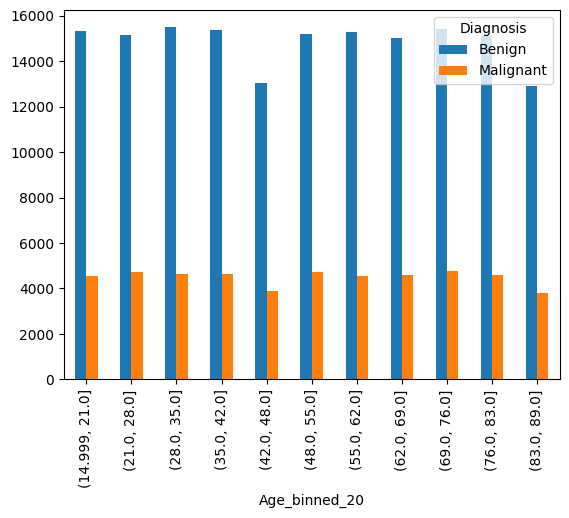

In [47]:
age_binned['Age_binned_20'] = pd.qcut(df['Age'],q=11)
age_binned.groupby(['Age_binned_20','Diagnosis']).size().unstack().plot(kind='bar')

After plotting a few different distributions I don't really see much predictive power in the Age group, but when binning by groups of 10 (0-10, 11-20, etc), it appears that there is a somewhat Gaussian shaped distribution in the age. I will use this as a feature

### Actionable Insights:

1. Age feature should be binned by ranges of 10 years 0-10, 11-20, etc.

## TSH, T3, and T4 Serum Levels

According the the American Cancer Society (https://www.cancer.org/cancer/types/thyroid-cancer/detection-diagnosis-staging/how-diagnosed.html) the levels of T3, T4, and TSH in the blood are normal for people with thyroid cancer. I think dropping these features might be useful because we are finding if a nodule is malignant or benign, not if cancer is still in the body after removal.

I have asked the dataset owner about the removal of the thyroid and nodule and I am awaiting a reply.

### Actionable Insights:

1. Group data by diagnosis and see if the serum levels are typically lower or higher in the malignant diagnosed patients.
2. Bin the TSH, T3, and T4 levels as low, normal, high (0,1,2)
3. Check for clusters in data.

In [53]:
#Extract serum feats and target
serum_feats = ['T3_Level','T4_Level','TSH_Level','Nodule_Size','Diagnosis']
serum_data = df[serum_feats]

In [52]:
#Check ranges
print(serum_data.min())
print(serum_data.max())

T3_Level          0.5
T4_Level          4.5
TSH_Level         0.1
Nodule_Size       0.0
Diagnosis      Benign
dtype: object
T3_Level             3.5
T4_Level            12.0
TSH_Level           10.0
Nodule_Size          5.0
Diagnosis      Malignant
dtype: object


Given the ranges for T3 and T4 levels, these appear to be the total T3 and total T4 levels, not bound or unbound.

In [55]:
#Bin serum into levels
t3_bins = [0,0.8,2.0,float('inf')]
t4_bins = [0,4.5,12,float('inf')]
tsh_bins = [0,0.4,4.0,float('inf')]
labels = [0,1,2]

serum_data['T3_Level_binned'] = pd.cut(serum_data['T3_Level'], bins=t3_bins, labels=labels, right=False)
serum_data['T4_Level_binned'] = pd.cut(serum_data['T4_Level'], bins=t4_bins, labels=labels, right=False)
serum_data['TSH_Level_binned'] = pd.cut(serum_data['TSH_Level'], bins=tsh_bins, labels=labels, right=False)

/tmp/ipykernel_35/2435444473.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  serum_data['T3_Level_binned'] = pd.cut(serum_data['T3_Level'], bins=t3_bins, labels=labels, right=False)
/tmp/ipykernel_35/2435444473.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  serum_data['T4_Level_binned'] = pd.cut(serum_data['T4_Level'], bins=t4_bins, labels=labels, right=False)
/tmp/ipykernel_35/2435444473.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .lo

In [68]:
from sklearn.cluster import KMeans

#K-means cluster of serum data
km = KMeans(n_clusters=3)
serum_data['km_clusters'] = km.fit_predict(serum_data[['T3_Level_binned','T4_Level_binned','TSH_Level_binned']])

cluster_arr = serum_data.groupby('km_clusters')['Diagnosis'].value_counts(normalize=True)
cluster_arr

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/tmp/ipykernel_35/1956758014.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  serum_data['km_clusters'] = km.fit_predict(serum_data[['T3_Level_binned','T4_Level_binned','TSH_Level_binned']])


km_clusters  Diagnosis
0            Benign       0.767472
             Malignant    0.232528
1            Benign       0.766404
             Malignant    0.233596
2            Benign       0.768135
             Malignant    0.231865
Name: proportion, dtype: float64

Clustering by hormone levels does not give results significantly different from the baseline.

### Actionable Insights:
1. Try different grouping levels.
2. Include other features in the clusters (Age, Nodule Size, Gender)

In [73]:
serum_data['Age'] = df['Age']
serum_data['Gender'] = df['Gender'].apply(lambda x:1 if x=='Male' else 0)

serum_data['km_clusters_extended'] = km.fit_predict(serum_data[['T3_Level_binned','T4_Level_binned','TSH_Level_binned','Gender','Age','Nodule_Size']])
serum_data.groupby('km_clusters_extended')['Diagnosis'].value_counts(normalize=True)



/tmp/ipykernel_35/4082505971.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  serum_data['Age'] = df['Age']
/tmp/ipykernel_35/4082505971.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  serum_data['Gender'] = df['Gender'].apply(lambda x:1 if x=='Male' else 0)
/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/tmp/ipykerne

km_clusters_extended  Diagnosis
0                     Benign       0.767736
                      Malignant    0.232264
1                     Benign       0.766694
                      Malignant    0.233306
2                     Benign       0.767471
                      Malignant    0.232529
Name: proportion, dtype: float64

I don't see any appreciable difference between baseline data and serum. Most diagnosticians only use serum levels to determine what steps to take next in the diagnostic process. I don't believe that these serum levels are useful for a machine learning algorithm. But to be sure, I will try a supervised learning method to see if it can detect any relationships I might be missing.

### Actionable Insights:

1. Use a random forest on **T3_Level**, **T4_Level**, and **TSH_Level** to detect dependency.

In [75]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

X = df[['T3_Level','T4_Level','TSH_Level','Nodule_Size']]
y = df['Diagnosis']

val_scores = cross_val_score(RandomForestClassifier(), X, y, scoring='f1_macro',cv=5)
print(val_scores.mean())

0.44249973985185126


The mean of my f1-scores gives about a 44% success, which means the random forest was able to seperate the data into classes and the result was different from the 77% benign/23% malignant imbalance present in the data. In other words, there is some predictive power in these features but it might not be very easy to find. There are two more possible options, feature engineering and deep learning.

### Actionable Insights:
1. Try a TSH/(T3+T4) feature. (Because TSH and T3/T4 levels are inverses of each other if one increases the other decreases)
2. Try scaling TSH, T3, and T4 levels with a square root or log transform.
3. Try a deep learning algorithm.

In [78]:
serum_data['serum_engineered'] = serum_data['TSH_Level']/(serum_data['T3_Level']+serum_data['T4_Level'])
serum_data['serum_engineered_root'] = np.sqrt(serum_data['serum_engineered'])
serum_data['serum_engineered_log'] = np.log1p(serum_data['serum_engineered'])

/tmp/ipykernel_35/4136745690.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  serum_data['serum_engineered'] = serum_data['TSH_Level']/(serum_data['T3_Level']+serum_data['T4_Level'])
/tmp/ipykernel_35/4136745690.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  serum_data['serum_engineered_root'] = np.sqrt(serum_data['serum_engineered'])
/tmp/ipykernel_35/4136745690.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] 

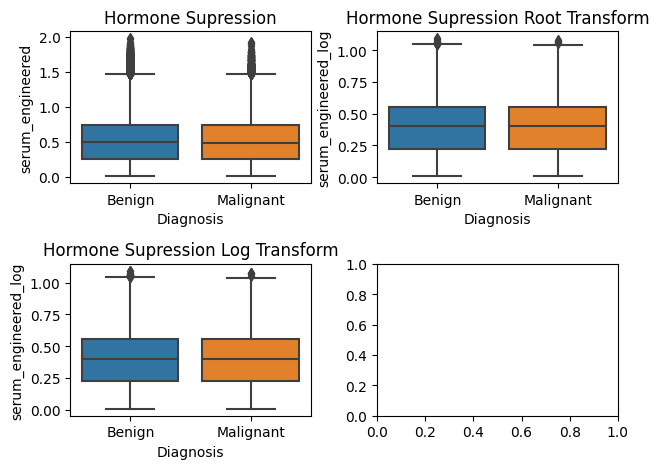

In [96]:
fig,axs = plt.subplots(2,2)
sns.boxplot(x='Diagnosis',y='serum_engineered',data=serum_data,ax=axs[0,0])
sns.boxplot(x='Diagnosis',y='serum_engineered_log',data=serum_data,ax=axs[0,1])
sns.boxplot(x='Diagnosis',y='serum_engineered_log',data=serum_data,ax=axs[1,0])
axs[0,0].set_title('Hormone Supression')
axs[0,1].set_title('Hormone Supression Root Transform')
axs[1,0].set_title('Hormone Supression Log Transform')

plt.tight_layout()


I have tried to plot the engineered feature, the square root, and the log but I don't see any differences in the distribution between malignant and benign diagnoses.

### Actionable Insights:
1. Try a deep learning algorithm.
2. Try engineering features by checking distribution and transforming the distribution into a more Gaussian shape (if possible).
3. Try taking ratios of features (e.g., T3:T4, T3:TSH, T4:TSH, and TSH:(T3+T4) <- TSH Supression.


In [10]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report

df = pd.read_csv('/kaggle/input/thyroid-cancer-risk-dataset/thyroid_cancer_risk_data.csv').drop(columns=['Patient_ID'])

/kaggle/input/thyroid-cancer-risk-dataset/thyroid_cancer_risk_data.csv


In [8]:
#Get serum features
X = df[['T3_Level','T4_Level','TSH_Level','Nodule_Size']]
y = LabelEncoder().fit_transform(df['Diagnosis'])

#Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Split to train/test sets
X_train, X_valid, y_train, y_valid = train_test_split(X_scaled, y, test_size=0.2, stratify=y)

#Calculate initial weights (target is imbalanced)
class_weights = compute_class_weight('balanced',classes=np.unique(y_train), y=y_train)
weights = {i:class_weights[i] for i in range(len(class_weights))}

In [15]:
model = Sequential([
    Dense(32, activation='relu',input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(16, activation='relu'),
    BatchNormalization(),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy','recall'])

history = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    epochs=100,
    batch_size=32,
    class_weight=weights,
    verbose=1
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
5318/5318 ━━━━━━━━━━━━━━━━━━━━ 33s 5ms/step - accuracy: 0.4906 - loss: 0.7109 - recall: 0.5125 - val_accuracy: 0.5235 - val_loss: 0.6905 - val_recall: 0.4590
Epoch 2/100
5318/5318 ━━━━━━━━━━━━━━━━━━━━ 26s 5ms/step - accuracy: 0.4966 - loss: 0.6955 - recall: 0.5051 - val_accuracy: 0.6181 - val_loss: 0.6866 - val_recall: 0.2680
Epoch 3/100
5318/5318 ━━━━━━━━━━━━━━━━━━━━ 26s 5ms/step - accuracy: 0.5232 - loss: 0.6931 - recall: 0.4514 - val_accuracy: 0.5323 - val_loss: 0.6882 - val_recall: 0.4525
Epoch 4/100
5318/5318 ━━━━━━━━━━━━━━━━━━━━ 26s 5ms/step - accuracy: 0.5231 - loss: 0.6933 - recall: 0.4611 - val_accuracy: 0.5489 - val_loss: 0.6917 - val_recall: 0.3995
Epoch 5/100
5318/5318 ━━━━━━━━━━━━━━━━━━━━ 26s 5ms/step - accuracy: 0.5210 - loss: 0.6932 - recall: 0.4616 - val_accuracy: 0.5402 - val_loss: 0.6941 - val_recall: 0.4250
Epoch 6/100
5318/5318 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - accuracy: 0.5740 - loss: 0.6907 - recall: 0.3657 - val_accuracy: 0.5338 - val_loss: 0.6933 -

In [17]:
with open('/kaggle/working/small_model_history.pkl','wb') as f:
    pickle.dump(history.history, f)

In [18]:
y_pred = model.predict(X_valid).flatten()
y_pred_class = (y_pred > 0.5).astype(int)

print(classification_report(y_valid, y_pred_class, target_names=['Benign','Malignant']))

1330/1330 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
              precision    recall  f1-score   support

      Benign       0.77      0.61      0.68     32640
   Malignant       0.23      0.39      0.29      9899

    accuracy                           0.56     42539
   macro avg       0.50      0.50      0.49     42539
weighted avg       0.64      0.56      0.59     42539



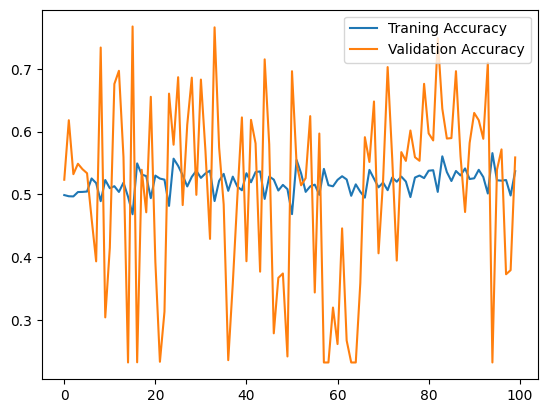

In [19]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],label='Traning Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.legend()
plt.show()

Due to the noise and the low precision and recall scores I don't think these features are worth keeping.

### Actionable Insights:
1. Drop the serum classes.
2. Train two models, one with and one without the data.
3. Try over sampling data

# Feature Engineering

## Check Distributions of Continuous Features

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

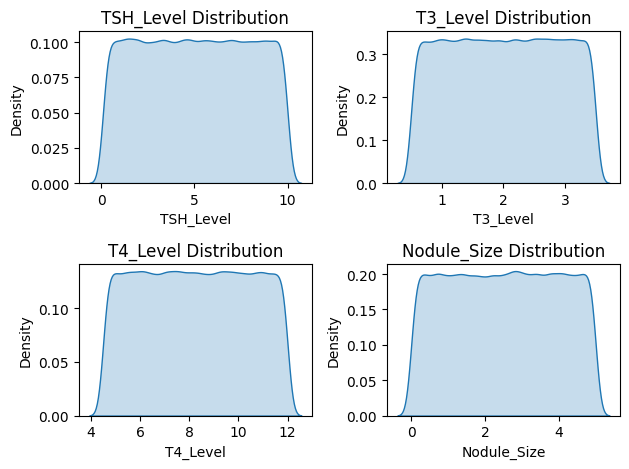

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

continuous_feats = ['TSH_Level','T3_Level','T4_Level','Nodule_Size']

#Plot distributions
fig,axs = plt.subplots(2,2)

for ax,feat in zip(axs.flatten(), continuous_feats):
    sns.kdeplot(data=df,x=feat,ax=ax, fill=True)
    ax.set_title(f"{feat} Distribution")
plt.tight_layout()

They all look the same with no scaling. To verify this I will overlay all plots onto one figure.

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

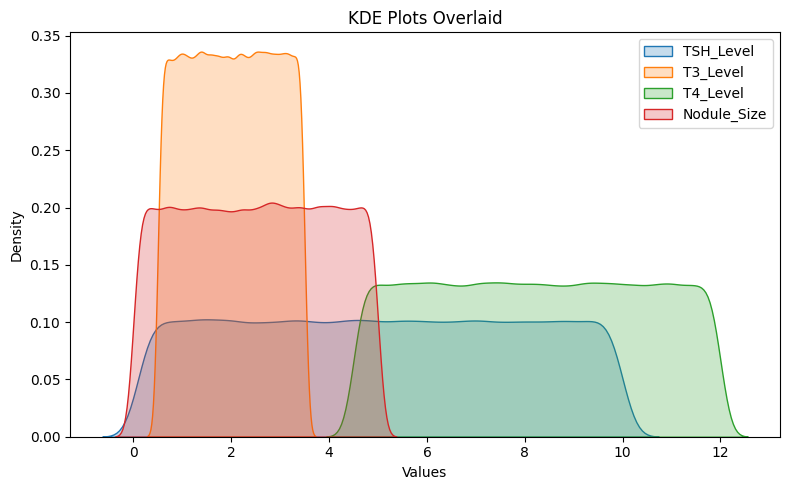

In [33]:
continuous_feats = ['TSH_Level','T3_Level','T4_Level','Nodule_Size']

plt.figure(figsize=(8,5))
for feat in continuous_feats:
    sns.kdeplot(x=df[feat],label=feat,fill=True)

plt.title('KDE Plots Overlaid')
plt.xlabel('Values')
plt.legend()
plt.tight_layout()
plt.show()

The plots are different distributions, but have similar shapes. The result from the previous KDE plots were just scaled differently. Given the shape of these graphs, my data is either closly packed into groups and those groups are evenly spread out or the data is just uniformly spread out.

### Actionable Insights:
1. Use a 1-Dimensional K-Means clustering algorithm to how many bins. 

Boundaries for TSH_Level are: [0, 0.96, 1.84, 2.77, 3.73, 4.7, 5.66, 6.58, 7.48, 8.34, 9.18, inf]
Boundaries for T3_Level are: [0, 0.78, 1.05, 1.3, 1.55, 1.8, 2.07, 2.35, 2.65, 2.94, 3.23, inf]
Boundaries for T4_Level are: [0, 5.14, 5.79, 6.47, 7.16, 7.86, 8.58, 9.3, 10.02, 10.72, 11.38, inf]
Boundaries for Nodule_Size are: [0, 0.43, 0.87, 1.33, 1.81, 2.27, 2.71, 3.15, 3.6, 4.06, 4.54, inf]


Text(0.5, 1.0, 'Violin Plot')

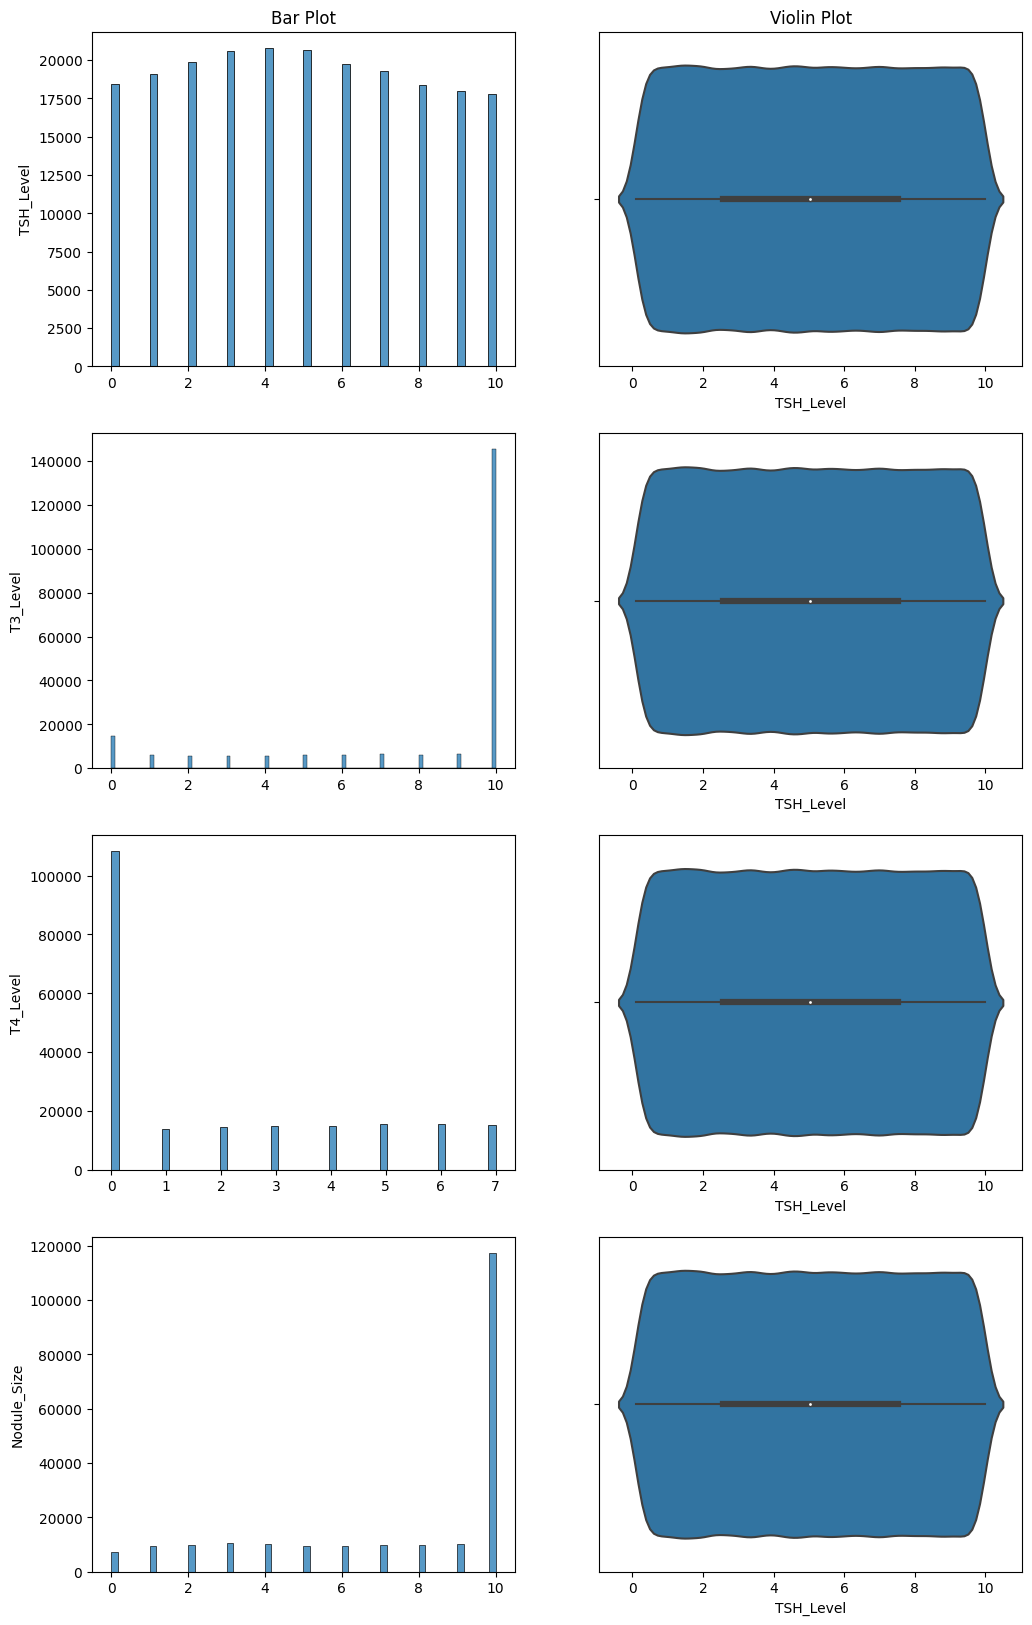

In [155]:
## Find cluster edges and centers from elbow method

#Set global variables and storage
continuous_feats = ['TSH_Level','T3_Level','T4_Level','Nodule_Size']
cluster_dict = {}

#Iterate through features
for feat in continuous_feats:
    #Fit kmeans clusters
    X = df[[feat]]
    df[feat+'_cluster'] = np.nan
    df.loc[X.index, feat+'_cluster'] = kmeans.fit_predict(X)

    #Find centers of each cluster
    centers = np.sort([kmeans.cluster_centers_.flatten()])
    labels = kmeans.labels_

    #Initialize storage and variables
    edges = []
    df_sorted = df.loc[X.index].sort_values(by=feat)
    prev_label = labels[df_sorted.index[0]]

    #Find bin edges
    for i in df_sorted.index:
        current_label = labels[i]
        if current_label != prev_label:
            edges.append(df_sorted.loc[i,feat])
            prev_label = current_label
    edges = [0]+edges
    edges.append(np.inf)
    cluster_dict[feat] = {'edges':edges,'centers':centers}
    print(f"Boundaries for {feat} are: {edges}")

fig, axs = plt.subplots(len(continuous_feats),2,figsize=(12,20))

for i,feat in enumerate(continuous_feats):
    plt_data = list(pd.cut(df['TSH_Level'],bins=cluster_dict[feat]['edges'],labels=range(len(binrange)-1),right=False))
    sns.histplot(data=plt_data, ax=axs[i,0])

    sns.violinplot(x=df['TSH_Level'],ax=axs[i,1],inner='box')

    axs[i,0].set_ylabel(f"{feat}")

axs[0,0].set_title('Bar Plot')
axs[0,1].set_title('Violin Plot')

Text(0.5, 1.0, 'Violin Plot')

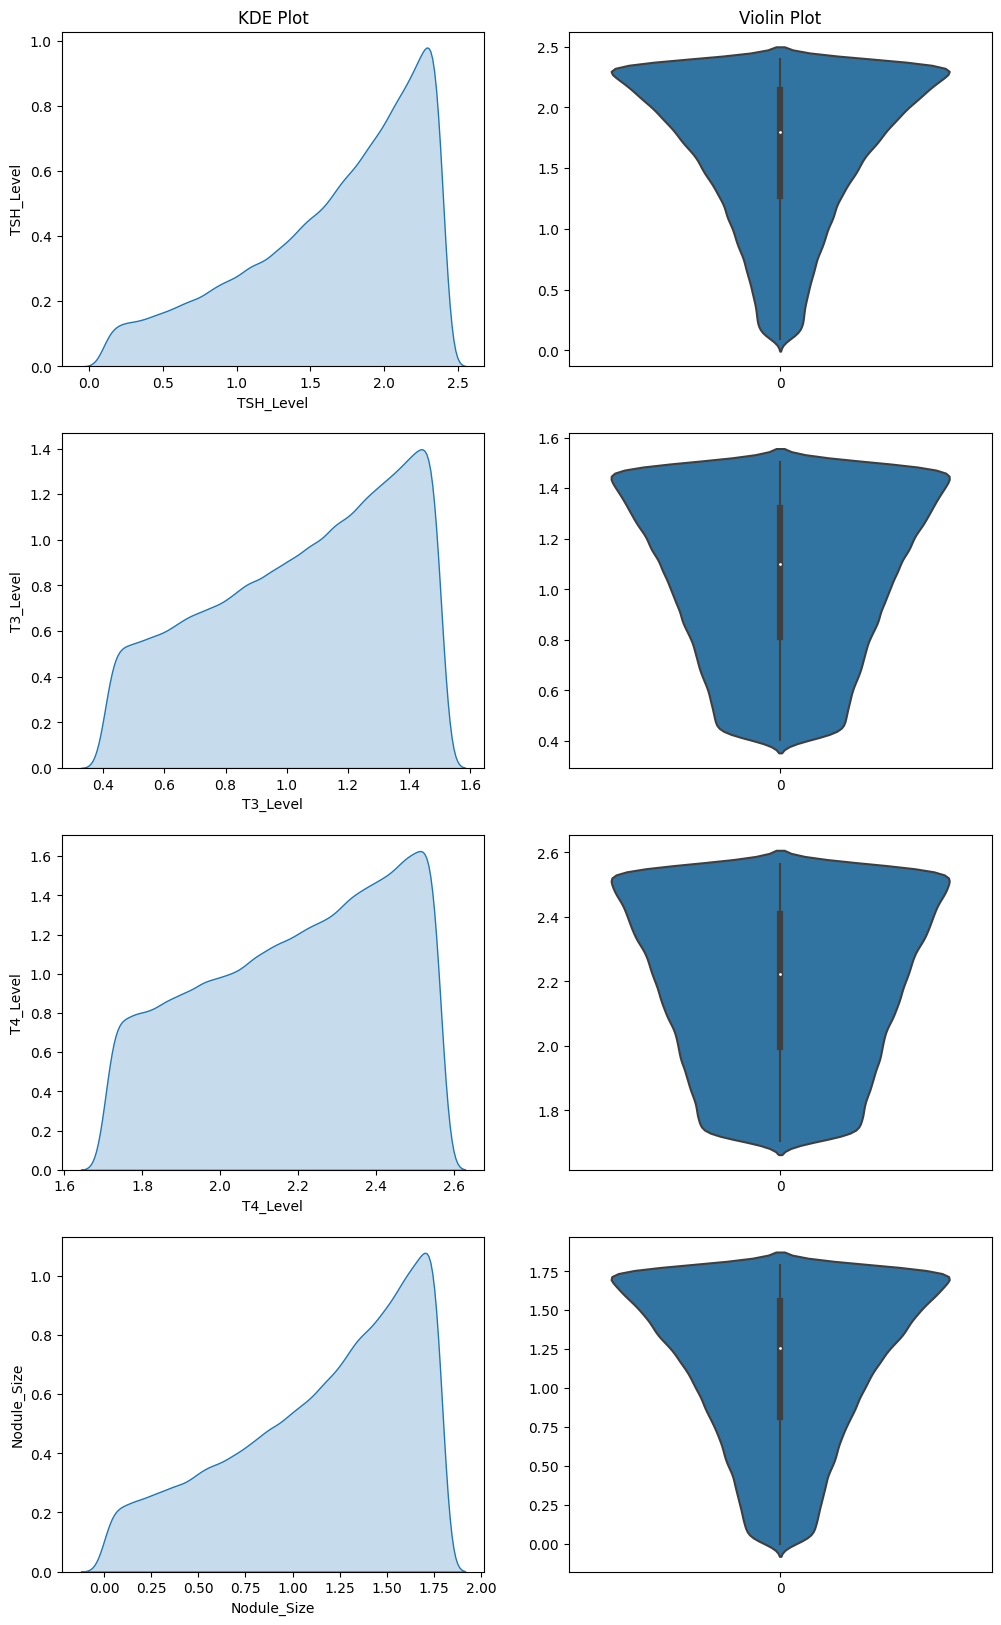

In [119]:
#Violin and KDE plot log transforms of features
fig, axs = plt.subplots(len(continuous_feats),2,figsize=(12,20))

for i,feat in enumerate(continuous_feats):
    sns.violinplot(np.log1p(df[feat]), ax=axs[i,1])
    sns.kdeplot(x=np.log1p(df[feat]),fill=True,ax=axs[i,0])
    axs[i,0].set_ylabel(feat)

axs[0,0].set_title('KDE Plot')
axs[0,1].set_title('Violin Plot')

Text(0.5, 1.0, 'Violin Plot')

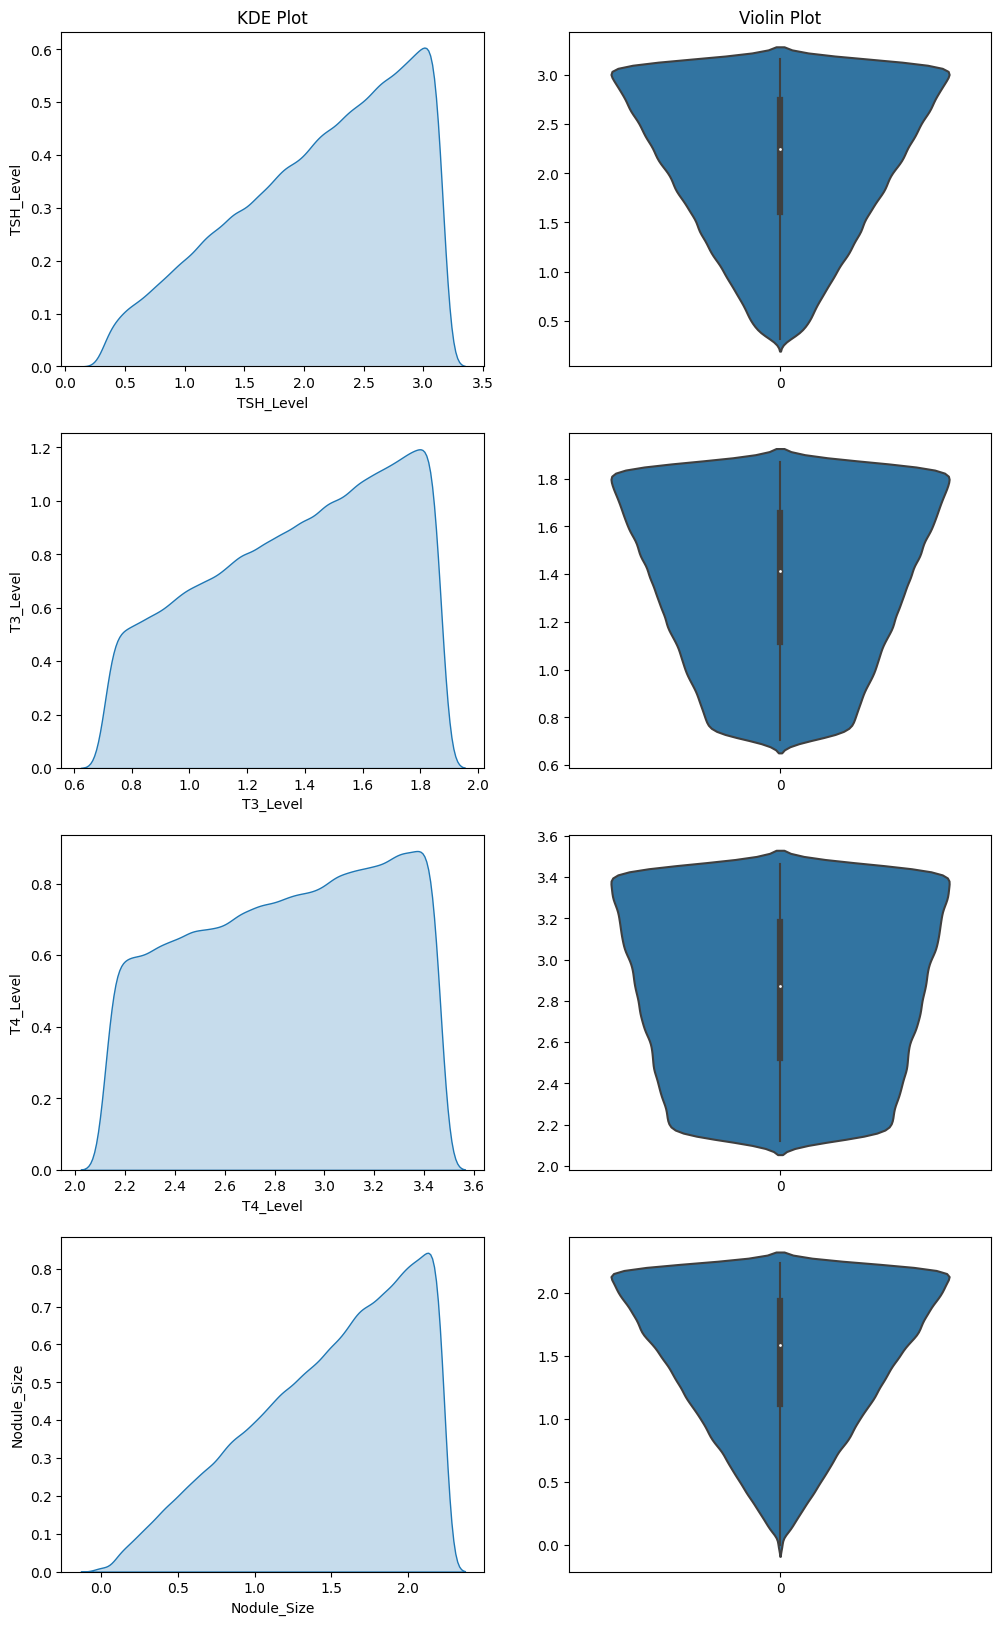

In [120]:
#Violin and KDE plot sqrt transforms of features
fig, axs = plt.subplots(len(continuous_feats),2,figsize=(12,20))

for i,feat in enumerate(continuous_feats):
    sns.violinplot(np.sqrt(df[feat]), ax=axs[i,1])
    sns.kdeplot(x=np.sqrt(df[feat]),fill=True,ax=axs[i,0])
    axs[i,0].set_ylabel(feat)

axs[0,0].set_title('KDE Plot')
axs[0,1].set_title('Violin Plot')

Text(0.5, 1.0, 'Violin Plots')

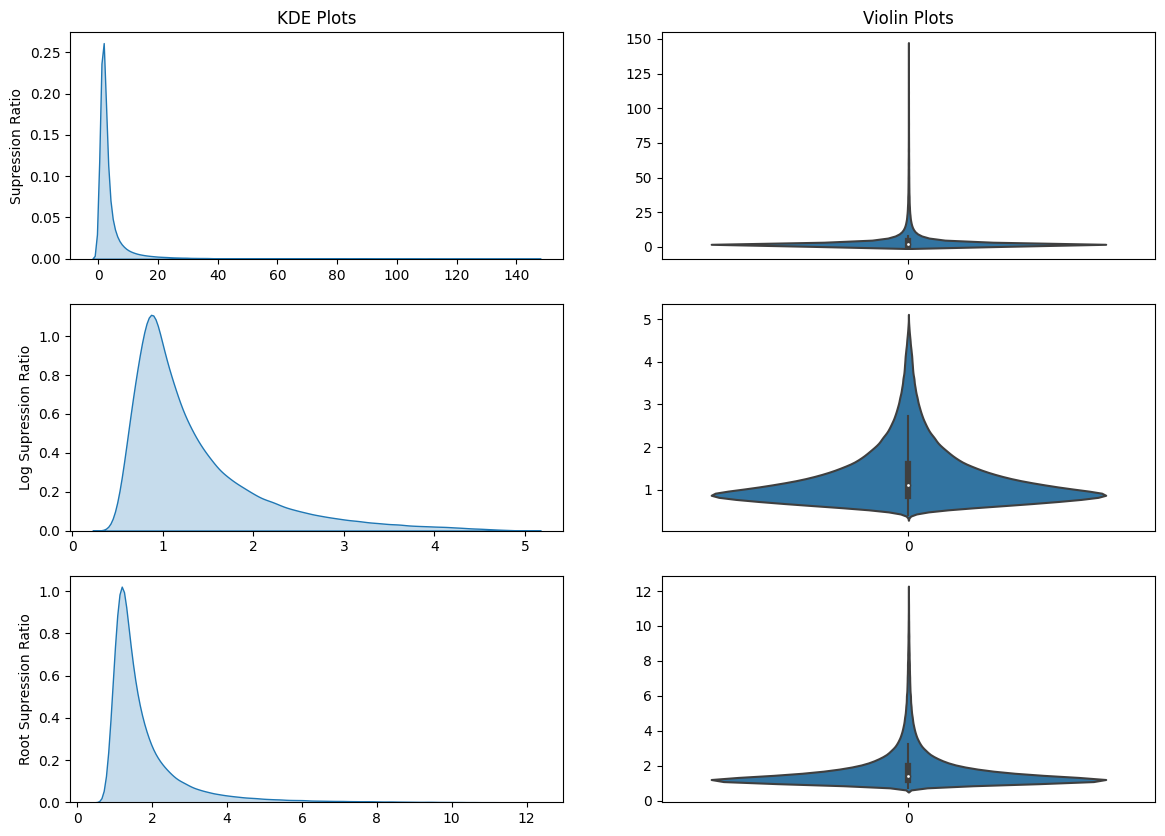

In [132]:
#Violin and KDE plot of supression ratio
supression = (df['T3_Level']+df['T4_Level'])/df['TSH_Level']
sup_log = np.log1p(supression)
sup_root = np.sqrt(supression)

supression_feat_list = [supression, sup_log, sup_root]
labels = ['Supression Ratio', 'Log Supression Ratio','Root Supression Ratio']

fig,axs = plt.subplots(3,2 ,figsize=(14,10))

for i, data in enumerate(supression_feat_list):
    sns.kdeplot(data,fill=True,ax=axs[i,0])
    sns.violinplot(data,ax=axs[i,1])
    axs[i,0].set_ylabel(labels[i])

axs[0,0].set_title('KDE Plots')
axs[0,1].set_title('Violin Plots')

Text(0.5, 1.0, 'Violin Plots')

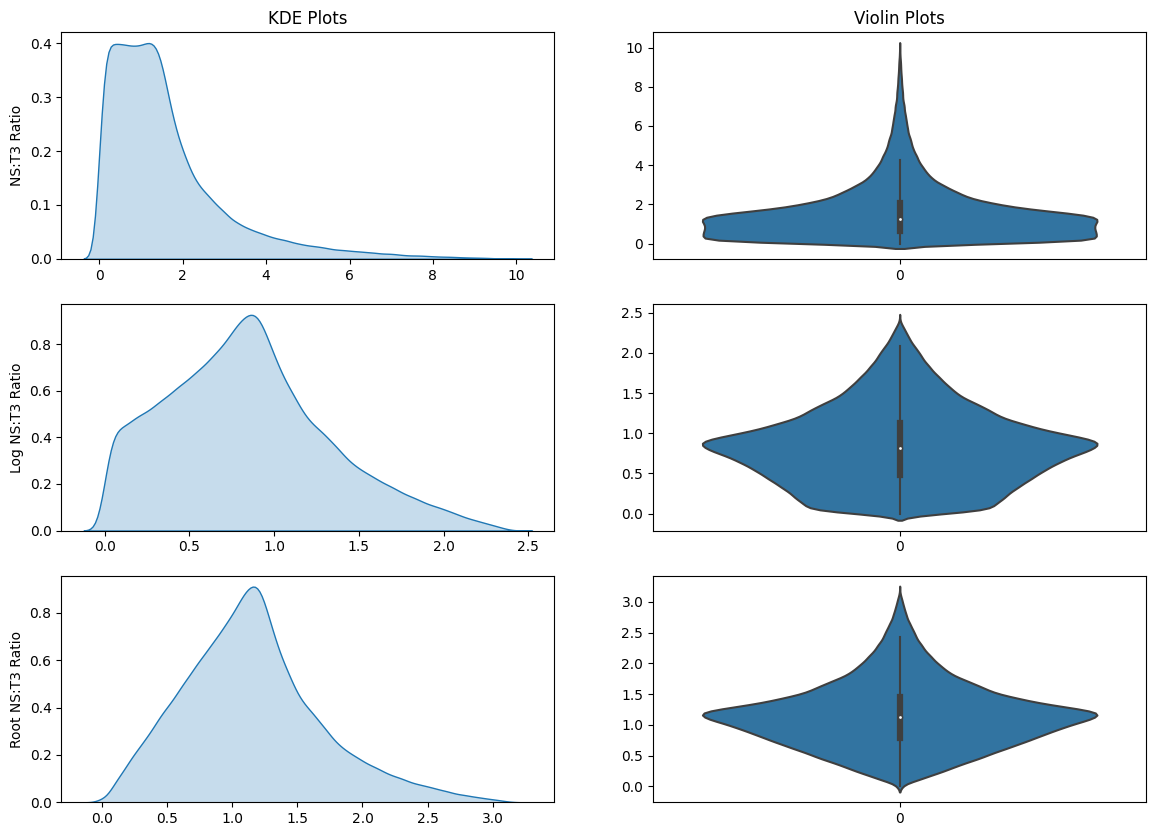

In [133]:
#Violin and KDE plot of Nodule_Size/T3
nst3 = df['Nodule_Size']/df['T3_Level']
nst3_log = np.log1p(nst3)
nst3_root = np.sqrt(nst3)

nst3_feat_list = [nst3, nst3_log, nst3_root]
labels = ['NS:T3 Ratio', 'Log NS:T3 Ratio','Root NS:T3 Ratio']

fig,axs = plt.subplots(3,2 ,figsize=(14,10))

for i, data in enumerate(nst3_feat_list):
    sns.kdeplot(data,fill=True,ax=axs[i,0])
    sns.violinplot(data,ax=axs[i,1])
    axs[i,0].set_ylabel(labels[i])

axs[0,0].set_title('KDE Plots')
axs[0,1].set_title('Violin Plots')

Text(0.5, 1.0, 'Violin Plots')

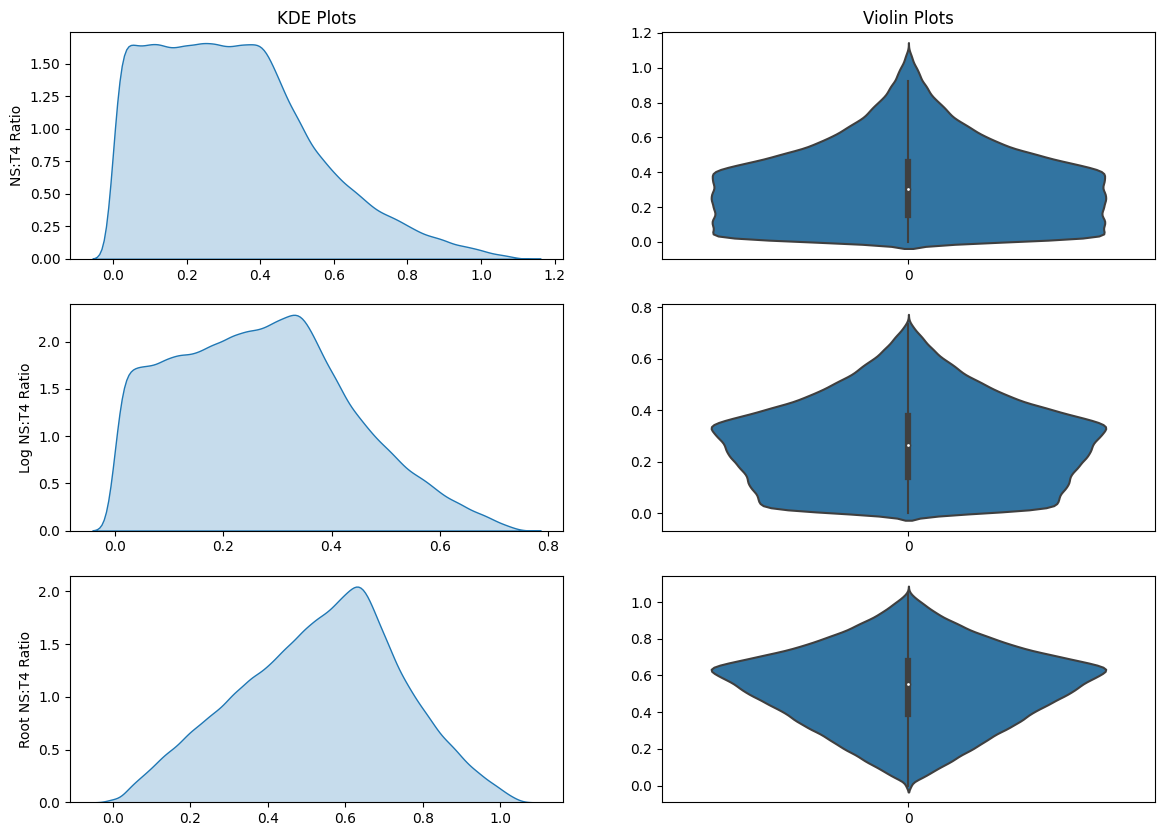

In [134]:
#Violin and KDE plot of Nodule_Size/T3
nst4 = df['Nodule_Size']/df['T4_Level']
nst4_log = np.log1p(nst4)
nst4_root = np.sqrt(nst4)

nst4_feat_list = [nst4, nst4_log, nst4_root]
labels = ['NS:T4 Ratio', 'Log NS:T4 Ratio','Root NS:T4 Ratio']

fig,axs = plt.subplots(3,2 ,figsize=(14,10))

for i, data in enumerate(nst4_feat_list):
    sns.kdeplot(data,fill=True,ax=axs[i,0])
    sns.violinplot(data,ax=axs[i,1])
    axs[i,0].set_ylabel(labels[i])

axs[0,0].set_title('KDE Plots')
axs[0,1].set_title('Violin Plots')

Text(0.5, 1.0, 'Violin Plots')

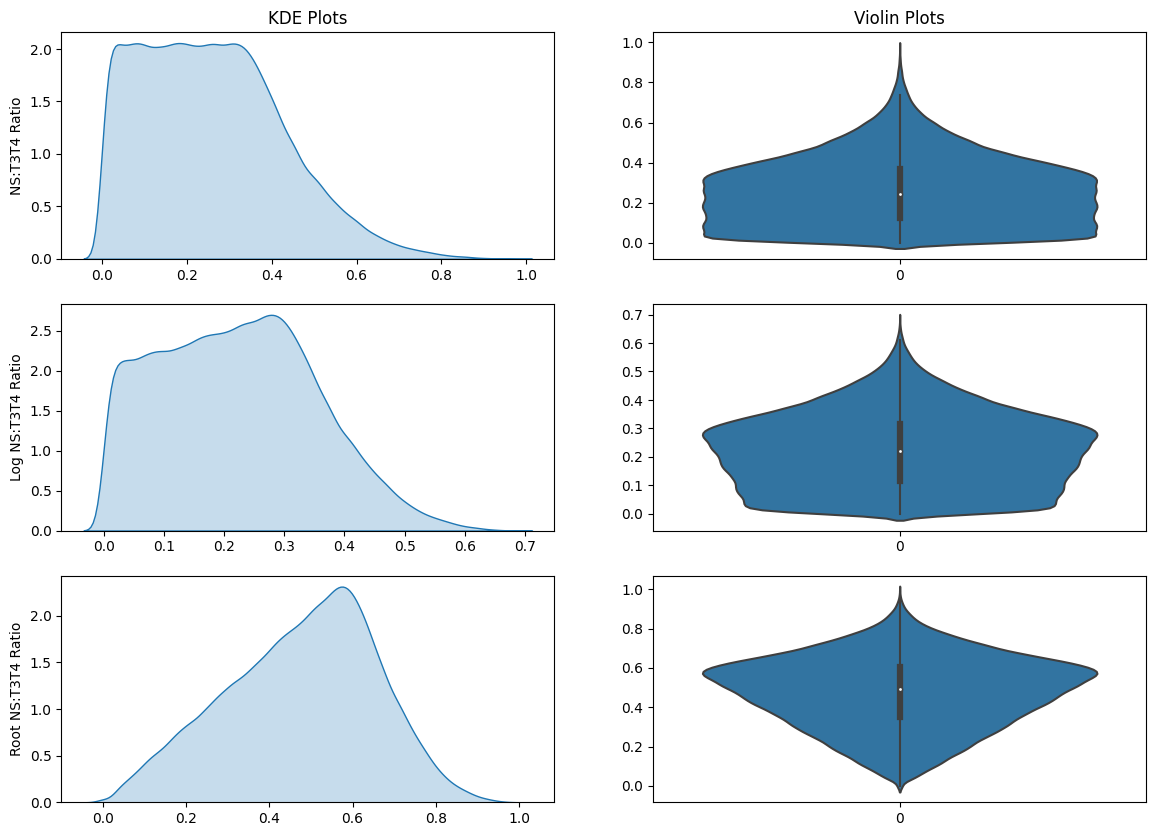

In [135]:
#Violin and KDE plot of Nodule_Size/(T3+T4)
nst3t4 = df['Nodule_Size']/(df['T3_Level']+df['T4_Level'])
nst3t4_log = np.log1p(nst3t4)
nst3t4_root = np.sqrt(nst3t4)

nst3t4_feat_list = [nst3t4, nst3t4_log, nst3t4_root]
labels = ['NS:T3T4 Ratio', 'Log NS:T3T4 Ratio','Root NS:T3T4 Ratio']

fig,axs = plt.subplots(3,2 ,figsize=(14,10))

for i, data in enumerate(nst3t4_feat_list):
    sns.kdeplot(data,fill=True,ax=axs[i,0])
    sns.violinplot(data,ax=axs[i,1])
    axs[i,0].set_ylabel(labels[i])

axs[0,0].set_title('KDE Plots')
axs[0,1].set_title('Violin Plots')

Text(0.5, 1.0, 'Violin Plots')

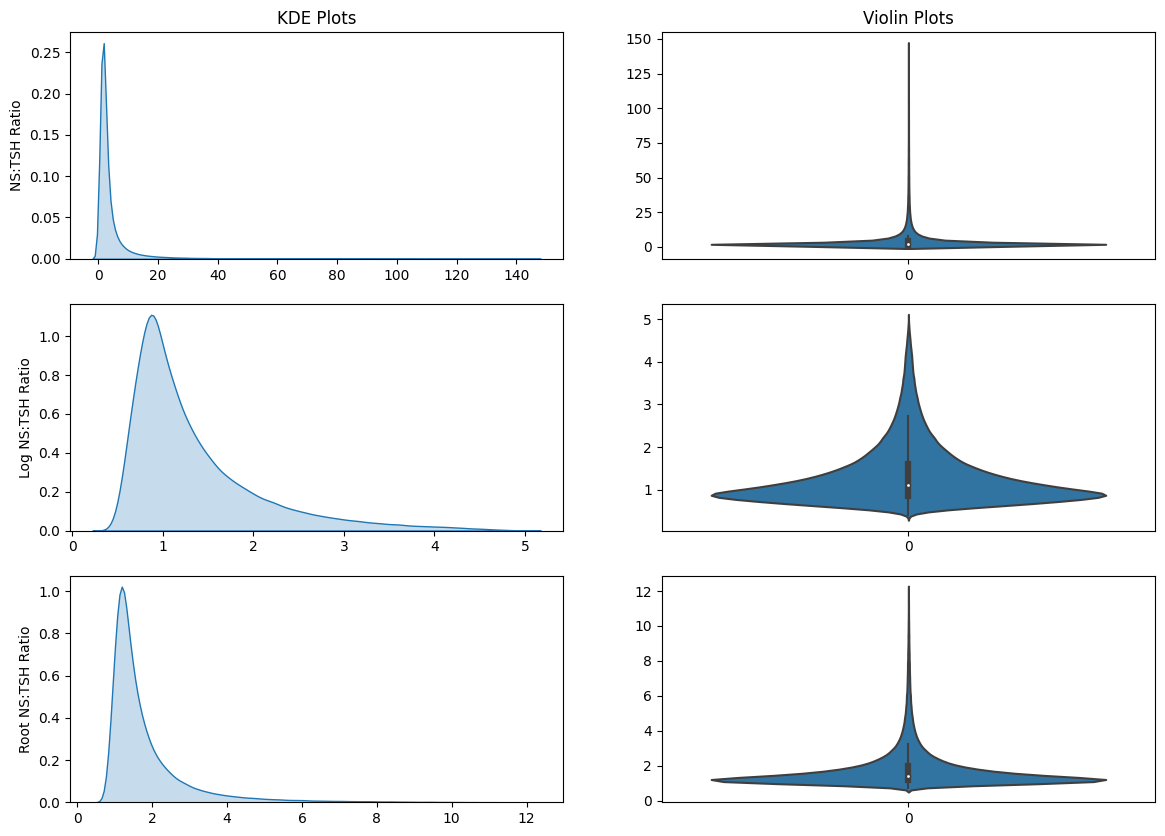

In [136]:
#Violin and KDE plot of Nodule_Size/TSH
nstsh = df['Nodule_Size']/df['TSH_Level']
nstsh_log = np.log1p(nst3)
nstsh_root = np.sqrt(nst3)

nstsh_feat_list = [nstsh, nstsh_log, nstsh_root]
labels = ['NS:TSH Ratio', 'Log NS:TSH Ratio','Root NS:TSH Ratio']

fig,axs = plt.subplots(3,2 ,figsize=(14,10))

for i, data in enumerate(supression_feat_list):
    sns.kdeplot(data,fill=True,ax=axs[i,0])
    sns.violinplot(data,ax=axs[i,1])
    axs[i,0].set_ylabel(labels[i])

axs[0,0].set_title('KDE Plots')
axs[0,1].set_title('Violin Plots')

It looks like the engineered features TSH/(T3+T4) and Nodule_Size/TSH, with the square log taken seem to give good, skewed shapes. I need to investigate if these have any predictive power. Remembering that the class imbalances are approximately 77% Benign and 23% Malignant.

### Actionable Insights:
1. Check the distribution of log1p(TSH/(T3+T4)) and log1p(Nodule_Size/TSH)

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

Text(0, 0.5, '')

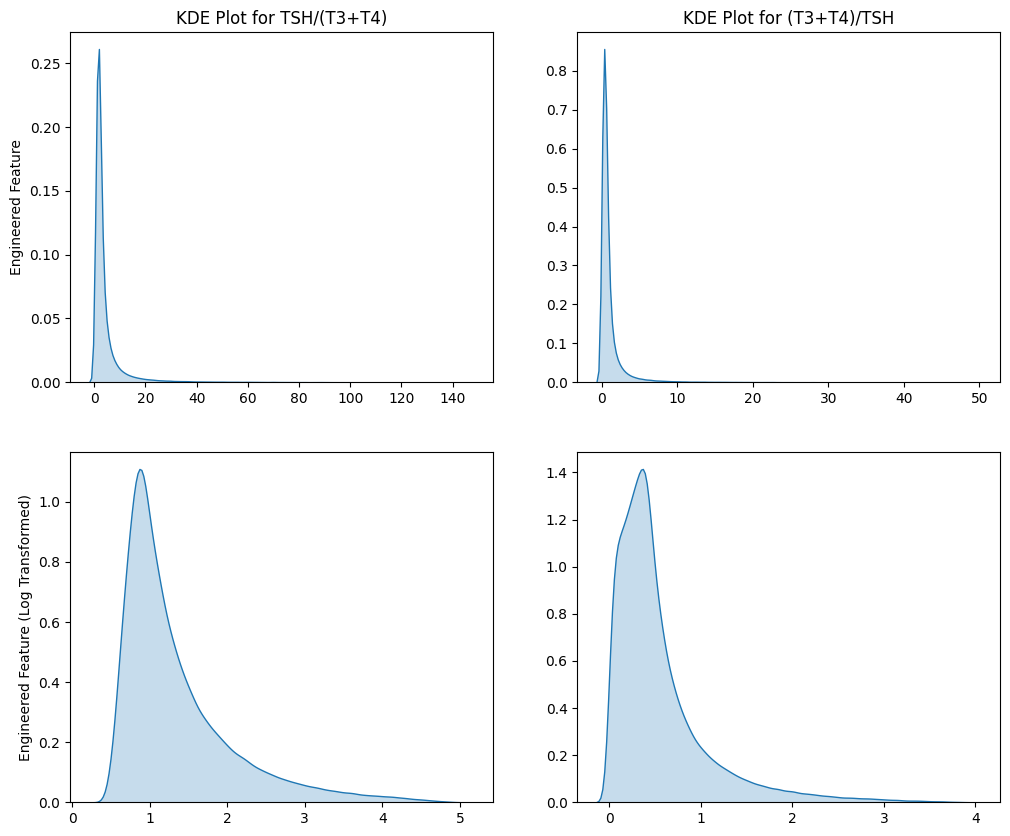

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

distro_1 = (df['T3_Level']+df['T4_Level'])/df['TSH_Level']
distro_2 = df['Nodule_Size']/df['TSH_Level']

fig, axs = plt.subplots(2,2,figsize=(12,10))
sns.kdeplot(distro_1,fill=True,ax=axs[0,0])
sns.kdeplot(distro_2, fill=True, ax=axs[0,1])

sns.kdeplot(np.log1p(distro_1),fill=True,ax=axs[1,0])
sns.kdeplot(np.log1p(distro_2),fill=True, ax=axs[1,1])

axs[0,0].set_title('KDE Plot for TSH/(T3+T4)')
axs[0,0].set_ylabel('Engineered Feature')
axs[0,1].set_title('KDE Plot for (T3+T4)/TSH')
axs[1,0].set_ylabel('Engineered Feature (Log Transformed)')
axs[1,1].set_ylabel('')
axs[0,1].set_ylabel('')

The logarithms of ((T3+T_4)/TSH) and NS/TSH distributions look similar to one another, which sugguests some data leakage could be occuring through the TSH feature and it may sugguest some interaction between two or more of these features.

Let $s$ be a scaling factor, then:

$log(\frac{N}{T_{SH}}) = slog((\frac{T_3+T_4}{T_{SH}}))$

$\Rightarrow \frac{N}{T_{SH}} = e^s(\frac{T_3+T_4}{T_{SH}})$

Where $N$ is the Nodule_Size, $T_{SH}$ is TSH_Level, and $T_3$ and $T_4$ are the T3_Level and T4_Level.
Solving for $e^s$ gives:

$e^s = \frac{N}{(T_3+T_4)}$

Since s is just a scaling factor then $S=e^s$, which gives:

$S = \frac{N}{(T_3+T_4)}$

### Does this make sense?

Nodules can be either hot or cold. Hot nodules produce T3 and T4 hormones and cold nodules do not. Hot nodules are significantly less likely to be malignant.

As a nodule increases in size it has more cells, and if the nodule is hot it will produce more T3 and T4 hormone.

If $S$ is big, that means a large nodule and low hormone output. This means the nodule is not outputting hormones and is cold and has a higher probability of being malignant.

If $S$ is small, that means small nodule and high output. In otherwords, the nodule is outputting hormones and is therefor hot.

So, yes, the behavior of this $S$ scaling factor makes sense.

### Actionable Insights:
1. Try using TSH and $S$ as features, dropping Nodule_Size, T3_Level, and T4_Level.



I think this is enough knowledge about the dataset to start building actual models using the following features:

'Age','Gender','Ethnicity','Family_History','Radiation_Exposure','Iodine_Deficiency','Smoking','Obesity','Diabetes','TSH_Level',$S$, 'Thyroid_Cancer_Risk', and the target 'Diagonsis'.

### Models to Try:
1. Gradient Boosting (vanilla, XGBoost, CatBoost, LightGBM, maybe: NGBoost, HistGradientBoosting)
2. RandomForest (maybe Extra Trees)
3. K-Nearest Neighbors

### Other Methods to Try:
1. Upscaling the Malignant diagnosis class using SMOTE-Tomeks

# Build Models

## Set up Environment/Prepare Data

Note: All models can be run once the cells from all subsections under 'Set up Environment/Prepare Data' section have been run

In [2]:
!pip install scikeras --no-deps
!pip install -q imbalanced-learn==0.10.1 --no-deps

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.0/226.0 kB 6.7 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import joblib
import json
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import random

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, Callback

from keras.layers import Lambda, Conv1D,AveragePooling1D, MaxPooling1D, Flatten, ReLU, Add
from keras import Input, Model

from scikeras.wrappers import KerasClassifier

from scipy.stats import randint,uniform

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


encoded_feats = ['TSH_Level', 'T3_Level', 'T4_Level', 'Nodule_Size',
                 'Diagnosis', 'Gender_binary','Family_History_binary', 'Radiation_Exposure_binary',
                 'Iodine_Deficiency_binary', 'Smoking_binary', 'Obesity_binary',
                 'Diabetes_binary', 'Thyroid_Cancer_Risk_encoded', 'Ethnicity_African',
                 'Ethnicity_Asian', 'Ethnicity_Caucasian', 'Ethnicity_Hispanic',
                 'Ethnicity_Middle Eastern',
                ]
continuous_feats = ['TSH_Level','T3_Level','T4_Level','Nodule_Size']

df = pd.read_csv('/kaggle/input/thyroid-cancer-risk-dataset/thyroid_cancer_risk_data.csv').drop(columns=['Patient_ID'])

2025-06-25 18:22:09.824830: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750875730.081703      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750875730.157220      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


/kaggle/input/thyroid-cancer-risk-dataset/thyroid_cancer_risk_data.csv


## Encode Features/Drop Unusable Features

In [4]:
def encoder(X, ordinal_feats, onehot_feats,return_binaries=False,feat_engineer=False):
    #Get unique values for non-numeric feature
    unique_non_numeric = {}
    for feat in X.columns:
        if X[feat].dtype == 'object':
            unique_vals = df[feat].unique()
            unique_non_numeric[feat] = dict(zip(unique_vals,list(range(len(unique_vals)))))

    #Encode binary features
    binary_feat_names = []
    for feat,uniques in unique_non_numeric.items():
        if (len(uniques) == 2) and feat != 'Diagnosis':
            binary_feat_names.append(feat)
            X[feat+'_binary'] = X[feat].map(lambda x:uniques[x])

    #Encode ordinal features
    categories = [list(X[feat].unique()) for feat in ordinal_feats]
    ord_enc = OrdinalEncoder(categories=categories)
    X[[feat+'_encoded' for feat in ordinal_feats]] = ord_enc.fit_transform(X[ordinal_feats])

    #Encode categorical feats
    if len(onehot_feats) > 0:
        oh_enc = OneHotEncoder(sparse_output=False,drop=None)
        X_ = pd.DataFrame(oh_enc.fit_transform(X[onehot_feats]))
        X_.columns = oh_enc.get_feature_names_out(input_features=onehot_feats)
        X = pd.concat([X,X_],axis=1)

    #Engineer new features
    if feat_engineer == True:
        X['S'] = X['Nodule_Size']/(X['T3_Level']+X['T4_Level'])

        bins = list(range(0,101,10))
        X['Age_binned'] = pd.cut(
            X['Age'], 
            bins=bins,
            labels=False,
        )
    
    if return_binaries == True:
        return X, binary_feat_names
    else:
        return X
    

In [5]:
#Define variables for encoding/feature selection
ordinal_feats = ['Thyroid_Cancer_Risk',]
onehot_feats = []#['Ethnicity',] #Dropping country
model_feats = [
    'Diagnosis','Gender_binary','Family_History_binary','Radiation_Exposure_binary',
    'Iodine_Deficiency_binary','Smoking_binary','Obesity_binary','Diabetes_binary',
    'Thyroid_Cancer_Risk_encoded','Age_binned','S',
]

#Encode variables
df_encoded = encoder(df,ordinal_feats,onehot_feats,feat_engineer=True)

#Extract features
X = df_encoded[model_feats].copy()
y = X.pop('Diagnosis').apply(lambda x:1 if x=='Malignant' else 0) #0 is benign, 1 is malignant

#Split to train, test, and valid sets (need validation due to multiple models)
X_, X_valid, y_, y_valid = train_test_split(X,y, stratify=y, test_size=0.2)
X_train, X_test, y_train, y_test = train_test_split(X_, y_, stratify=y_, test_size=0.2)

#Resample training data for gradient boosting
resampler = SMOTETomek()
X_resample, y_resample = resampler.fit_resample(X_train,y_train)

print(f"Traning set resampled from {Counter(y_train)} to {Counter(y_resample)}")

Traning set resampled from Counter({0: 104444, 1: 31677}) to Counter({0: 82950, 1: 82950})


# Deep Learning

## Model #1 - Deep Learning Network (Expanding-Contracting)

In [91]:
def model_deep1():
    model = Sequential([
        keras.Input(shape=(X_train.shape[1],)),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy',metrics=['accuracy'])

    return model
    
early_stop = EarlyStopping(
    monitor='loss',
    patience=5,
    restore_best_weights=True,
)

keras_classifier_deep1 = KerasClassifier(
    model=model_deep1,
    epochs=75,
    batch_size=34,
    class_weight='balanced',
    verbose=1,
    callbacks=[early_stop]
)

pipeline_deep1 = ImbPipeline(steps=[
    ('smote',SMOTE(),),
    ('scaler',StandardScaler(),),
    ('model',keras_classifier_deep1,),
])


In [94]:
#Learning Rate 0.005
pipeline_deep1.fit(X_resample, y_resample)
y_pred_deep1 = pipeline_deep1.predict(X_test)

Epoch 1/75
4874/4874 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step - accuracy: 0.6271 - loss: 0.7205
Epoch 2/75
4874/4874 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.7132 - loss: 0.5715
Epoch 3/75
4874/4874 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.7378 - loss: 0.5416
Epoch 4/75
4874/4874 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.7428 - loss: 0.5349
Epoch 5/75
4874/4874 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.7463 - loss: 0.5309
Epoch 6/75
4874/4874 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.7488 - loss: 0.5272
Epoch 7/75
4874/4874 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.7505 - loss: 0.5249
Epoch 8/75
4874/4874 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.7487 - loss: 0.5254
Epoch 9/75
4874/4874 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.7473 - loss: 0.5277
Epoch 10/75
4874/4874 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.7497 - loss: 0.5256
Epoch 11/75
4874/4874 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.7499 - loss: 0.5244
Epoch 12/75
4874/48

In [95]:
#Generate Report
report_deep1 = pd.DataFrame(classification_report(y_test, y_pred_deep1, output_dict=True)).transpose()
report_deep1.to_csv('/kaggle/working/report_deep1.csv')
report_deep1

,precision,recall,f1-score,support
0,0.850313,0.941981,0.893803,26112.000000
1,0.703174,0.453214,0.551179,7919.000000
accuracy,0.828245,0.828245,0.828245,0.828245
macro avg,0.776743,0.697597,0.722491,34031.000000
weighted avg,0.816074,0.828245,0.814074,34031.000000


In [96]:
#Check false negatives with confusion matrix
cm_deep1 = confusion_matrix(y_test, y_pred_deep1)
print(cm_deep1[1,0]/(cm_deep1[1,0]+cm_deep1[1,1])) #Ratio of (false negative):(total malignant)

0.5467862103800984


In [97]:
#Save Results
pd.DataFrame({'y_true':y_test,'y_pred':y_pred_deep1}).to_csv('/kaggle/working/predictions_deep1.csv', index=False)

with open('/kaggle/working/scores_deep1.csv','w') as f:
    json.dump(classification_report(y_test, y_pred_deep1),f)

## Model #2 - Deep Learning Network (Contracting)

256->128->64->1(output)
Learn Rate: 0.001

In [98]:
def model_deep2():
    model = Sequential([
        keras.Input(shape=(X_train.shape[1],)),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy',metrics=['accuracy'])

    return model

    
early_stop = EarlyStopping(
    monitor='loss',
    patience=5,
    restore_best_weights=True,
)

keras_classifier_deep2 = KerasClassifier(
    model=model_deep2,
    epochs=75,
    batch_size=34,
    class_weight='balanced',
    verbose=1,
    callbacks=[early_stop]
)

pipeline_deep2 = ImbPipeline(steps=[
    ('smote',SMOTE(),),
    ('scaler',StandardScaler(),),
    ('model',keras_classifier_deep2,),
])


In [99]:
#Learning Rate = 0.001
pipeline_deep2.fit(X_resample, y_resample)
y_pred_deep2 = pipeline_deep2.predict(X_test)

Epoch 1/75
4874/4874 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.6505 - loss: 0.6883
Epoch 2/75
4874/4874 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.7290 - loss: 0.5518
Epoch 3/75
4874/4874 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.7446 - loss: 0.5360
Epoch 4/75
4874/4874 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.7485 - loss: 0.5302
Epoch 5/75
4874/4874 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.7466 - loss: 0.5293
Epoch 6/75
4874/4874 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.7494 - loss: 0.5269
Epoch 7/75
4874/4874 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.7490 - loss: 0.5266
Epoch 8/75
4874/4874 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.7499 - loss: 0.5240
Epoch 9/75
4874/4874 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.7497 - loss: 0.5237
Epoch 10/75
4874/4874 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.7485 - loss: 0.5244
Epoch 11/75
4874/4874 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.7495 - loss: 0.5254
Epoch 12/75
4874/48

In [100]:
#Generate Report
report_deep2 = pd.DataFrame(classification_report(y_test, y_pred_deep2, output_dict=True)).transpose()
report_deep2.to_csv('/kaggle/working/report_deep2.csv')
report_deep2

,precision,recall,f1-score,support
0,0.850313,0.941981,0.893803,26112.000000
1,0.703174,0.453214,0.551179,7919.000000
accuracy,0.828245,0.828245,0.828245,0.828245
macro avg,0.776743,0.697597,0.722491,34031.000000
weighted avg,0.816074,0.828245,0.814074,34031.000000


In [101]:
#Check false negatives of confusion matrix
cm_deep2 = confusion_matrix(y_test, y_pred_deep2)
print(cm_deep2[1,0]/(cm_deep2[1,0]+cm_deep2[1,1])) #Ratio of (false negative):(total malignant)

0.5467862103800984


In [102]:
#Save Results
pd.DataFrame({'y_true':y_test,'y_pred':y_pred_deep2}).to_csv('/kaggle/working/predictions_model2.csv', index=False)

with open('/kaggle/working/scores_deep2.csv','w') as f:
    json.dump(classification_report(y_test, y_pred_deep2),f)

# Gradient Boosting

## Build Gradient Boosting Model

In [103]:
#Define gridsearch parameters
params = {
    'n_estimators':[50,100,150],
    'learning_rate':[0.01, 0.05, 0.1],
    'max_depth':[3,5,10],
    'subsample':[0.6,0.8,1.0],
    'max_features':['sqrt','log2',None]
}

#Define hyperameter space
gb_param_dists = {
    'n_estimators':randint(50,300),
    'learning_rate':uniform(0.01, 0.3),
    'max_depth':randint(2,10),
    'subsample':uniform(0.7,0.3),
    'min_samples_split':randint(2,10),
    'min_samples_leaf':randint(1,10),
}

#Define estimator
gb_model = GradientBoostingClassifier()

#Create grid search model
gb_grid_search = GridSearchCV(
    estimator=gb_model,
    param_grid=params,
    cv=3,
    scoring='recall', #More concerned with missed malignancies than overall performance
    verbose=2,
)

#Create random search model
gb_random_search = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=gb_param_dists,
    n_iter=50,
    scoring='recall',
    cv=5,
    verbose=2,
    n_jobs=-1,
)


In [104]:
#Fit Model

gb_random_search.fit(X_resample, y_resample)
#gb_grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END learning_rate=0.25691729747951886, max_depth=5, min_samples_leaf=7, min_samples_split=6, n_estimators=75, subsample=0.799668327085126; total time=  23.2s
[CV] END learning_rate=0.06286572124313465, max_depth=4, min_samples_leaf=5, min_samples_split=6, n_estimators=272, subsample=0.9946174385745179; total time= 1.3min
[CV] END learning_rate=0.1959684020389547, max_depth=9, min_samples_leaf=5, min_samples_split=3, n_estimators=274, subsample=0.7614047870150404; total time= 2.3min
[CV] END learning_rate=0.1959684020389547, max_depth=9, min_samples_leaf=5, min_samples_split=3, n_estimators=274, subsample=0.7614047870150404; total time= 2.3min
[CV] END learning_rate=0.04540718996549185, max_depth=9, min_samples_leaf=5, min_samples_split=2, n_estimators=253, subsample=0.9964171922214264; total time= 2.6min
[CV] END learning_rate=0.21212551847626165, max_depth=2, min_samples_leaf=7, min_samples_split=6, n_estimators=59, su

RandomizedSearchCV(cv=5, estimator=GradientBoostingClassifier(), n_iter=50,
                   n_jobs=-1,
                   param_distributions={'learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7d64091e6f90>,
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7d640ae51910>,
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7d6428640150>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7d6428640350>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7d63bb3b75d0>,
                                        'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7d642b678c10>},
                   scoring='recall', verbose=2)

In [105]:
#Get best model
gb_best_model = gb_random_search.best_estimator_

#Get predictions and probabilities
y_pred_gb = gb_best_model.predict(X_test[feats])
y_probs_gb = gb_best_model.predict_proba(X_test[feats])[:,1]

In [109]:
#Get metrics
gb_conf_mat = confusion_matrix(y_test, y_pred_gb)
report_gb = classification_report(y_test, y_pred_gb, output_dict=True)

#Get importances
importances_gb = pd.Series(gb_best_model.feature_importances_, index=X_resample.columns)
importances_gb.sort_values(ascending=False).to_csv('importances_gb.csv')

#Save model
joblib.dump(gb_best_model,'/kaggle/working/gb_model.pkl')

#Save predictions
gb_pred_df = pd.DataFrame({
    'True':y_test,
    'Predicted':y_pred_gb,
    'Predicted Probability':y_probs_gb,
})
gb_pred_df.to_csv('/kaggle/working/predictions_gb.csv')

#Save report
pd.DataFrame(report_gb).to_csv('/kaggle/working/report_gb.csv')

### Visualize

In [110]:
print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.85      0.87      0.86     26112
           1       0.54      0.50      0.52      7919

    accuracy                           0.78     34031
   macro avg       0.69      0.68      0.69     34031
weighted avg       0.78      0.78      0.78     34031



Text(0.5, 1.0, 'Confusion Matrix for Gradient Boost (Vanilla)')

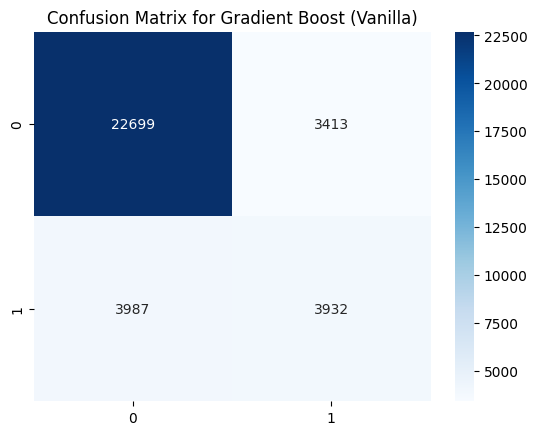

In [111]:
sns.heatmap(gb_conf_mat, annot=True, fmt='d',cmap='Blues')
plt.title('Confusion Matrix for Gradient Boost (Vanilla)')

## Build XGBoost Model

In [113]:
#Define hyperameter space
xgb_param_dists = {
    'n_estimators':randint(100,500),
    'max_depth': randint(3,10),
    'learning_rate':uniform(0.01,0.3),
    'subsample':uniform(0.7,0.3),
    'colsample_bytree':uniform(0.7,0.3),
    'gamma':uniform(0,0.5),
    'min_child_weight':randint(1,10)
}

#Define estimator
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder='False',
)

#Define random search function
xgb_random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_param_dists,
    n_iter=50,
    scoring='recall',
    cv=5,
    verbose=2,
    n_jobs=-1,
)

In [114]:
#Fit model with resampled data
xgb_random_search.fit(X_resample, y_resample)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END colsample_bytree=0.8592283967992984, gamma=0.010107273971620145, learning_rate=0.23619753517407155, max_depth=8, min_child_weight=4, n_estimators=268, subsample=0.8355260204904256; total time=   7.2s
[CV] END colsample_bytree=0.9089420343408725, gamma=0.04477917190222097, learning_rate=0.2624908765684378, max_depth=4, min_child_weight=6, n_estimators=373, subsample=0.8701711400805818; total time=   5.9s
[CV] END colsample_bytree=0.9089420343408725, gamma=0.04477917190222097, learning_rate=0.2624908765684378, max_depth=4, min_child_weight=6, n_estimators=373, subsample=0.8701711400805818; total time=   6.5s
[CV] END colsample_bytree=0.7637218183817501, gamma=0.15637880885218963, learning_rate=0.07853866714117883, max_depth=9, min_child_weight=7, n_estimators=321, subsample=0.9822377290148306; total time=   5.6s
[CV] END colsample_bytree=0.7624257187008473, gamma=0.23863261883247133, learning_rate=0.21000338036740798,

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning...
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7d642b198b50>,
                                        'min_child_weight': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7d642b101310>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7d642863ef10>,
                                        'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7d640aea0890>},
                   scoring='recall', verbose=2)

In [117]:
#Best model
xgb_best_model = xgb_random_search.best_estimator_

#Make predictions, get probabilities
y_pred_xgb = xgb_best_model.predict(X_test)
y_probs_xgb = xgb_best_model.predict_proba(X_test)[:,1]


In [120]:
#Get metrics
xgb_conf_mat = confusion_matrix(y_test, y_pred_xgb)
report_xgb = classification_report(y_test, y_pred_xgb, output_dict=True)


#Get feature importances
importances_xgb = pd.Series(xgb_best_model.feature_importances_, index=X_resample.columns)
importances_xgb.sort_values(ascending=False).to_csv('importances_xgb.csv')

#Save model
joblib.dump(xgb_best_model,'/kaggle/working/xgb_model.pkl')

#Save predictions
xgb_pred_df = pd.DataFrame({
    'True':y_test,
    'Predicted':y_pred_xgb,
    'Predicted Probability':y_probs_xgb,
})
xgb_pred_df.to_csv('/kaggle/working/predictions_xgb.csv')

#Save report
pd.DataFrame(report_xgb).to_csv('/kaggle/working/report_xgb.csv')



### Visualize Outputs

In [121]:
print(classification_report(y_test,y_pred_xgb))

              precision    recall  f1-score   support

           0       0.85      0.83      0.84     26112
           1       0.48      0.52      0.50      7919

    accuracy                           0.76     34031
   macro avg       0.66      0.67      0.67     34031
weighted avg       0.76      0.76      0.76     34031



Text(0.5, 1.0, 'Confusion Matrix for Best XGBoost Model')

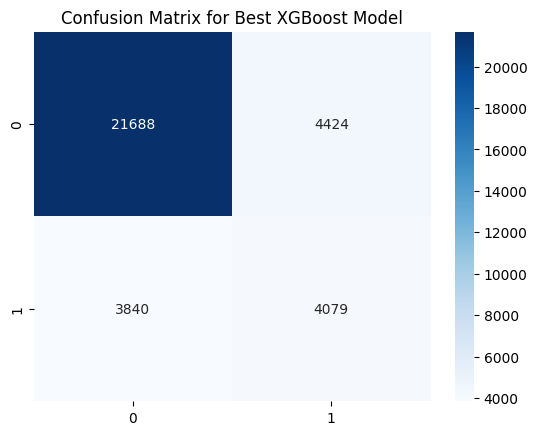

In [122]:
sns.heatmap(xgb_conf_mat, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Best XGBoost Model')

## Build CatBoost Model

In [125]:
#Define hyperameter space
cb_param_dists = {
    'depth':randint(4,10),
    'iterations':randint(100,900),
    'learning_rate':uniform(0.01, 0.25),
    'l2_leaf_reg':uniform(1,10),
    'border_count':randint(31,255)
}

#Define estimator
cb = CatBoostClassifier(
    eval_metric='Logloss',
    loss_function='Logloss',
    verbose=0
)

#Define random search function
cb_random_search = RandomizedSearchCV(
    estimator=cb,
    param_distributions=cb_param_dists,
    n_iter=50,
    scoring='recall',
    cv=5,
    verbose=2
)

In [127]:
#Fit model
cb_random_search.fit(X_resample,y_resample)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END border_count=243, depth=6, iterations=614, l2_leaf_reg=3.460849314015292, learning_rate=0.08957902457024867; total time=  10.3s
[CV] END border_count=243, depth=6, iterations=614, l2_leaf_reg=3.460849314015292, learning_rate=0.08957902457024867; total time=   9.6s
[CV] END border_count=243, depth=6, iterations=614, l2_leaf_reg=3.460849314015292, learning_rate=0.08957902457024867; total time=   9.4s
[CV] END border_count=243, depth=6, iterations=614, l2_leaf_reg=3.460849314015292, learning_rate=0.08957902457024867; total time=  10.6s
[CV] END border_count=243, depth=6, iterations=614, l2_leaf_reg=3.460849314015292, learning_rate=0.08957902457024867; total time=   9.4s
[CV] END border_count=42, depth=6, iterations=643, l2_leaf_reg=5.90137264370412, learning_rate=0.15743433102357052; total time=   9.7s
[CV] END border_count=42, depth=6, iterations=643, l2_leaf_reg=5.90137264370412, learning_rate=0.15743433102357052; to

RandomizedSearchCV(cv=5,
                   estimator=<catboost.core.CatBoostClassifier object at 0x7d63f561c6d0>,
                   n_iter=50,
                   param_distributions={'border_count': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7d645e8cadd0>,
                                        'depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7d6506316250>,
                                        'iterations': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7d645e8c9110>,
                                        'l2_leaf_reg': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7d645e8ca850>,
                                        'learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7d645e8c8bd0>},
                   scoring='recall', verbose=2)

In [128]:
#Get best model
cb_best_model = cb_random_search.best_estimator_

#Make predictions and get probabilities
y_pred_cb = cb_best_model.predict(X_test)
y_probs_cb = cb_best_model.predict_proba(X_test)[:,1]

In [ ]:
#Get metrics
cb_conf_mat = confusion_matrix(y_test,y_pred_cb)
report_cb = classification_report(y_test, y_pred_cb, output_dict=True)

#Get importances
importances_cb = pd.Series(cb_best_model.feature_importances_, index=X_resample.columns)
importances_cb.sort_values(ascending=False).to_csv('importances_cb.csv')

#Save model
joblib.dump(cb_best_model,'/kaggle/working/cb_model.pkl')

#Save predictions
cb_pred_df = pd.DataFrame({
    'True':y_test,
    'Predicted':y_pred_cb,
    'Predicted Probability':y_probs_cb,
})
cb_pred_df.to_csv('/kaggle/working/predictions_cb.csv')

#Save report
pd.DataFrame(report_cb).to_csv('/kaggle/working/report_cb.csv')




[CV] END colsample_bytree=0.785272299354753, learning_rate=0.24764390959590815, max_depth=2, min_child_samples=23, n_estimators=618, num_leaves=123, subsample=0.8359868719236174; total time=  11.7s
[CV] END colsample_bytree=0.785272299354753, learning_rate=0.24764390959590815, max_depth=2, min_child_samples=23, n_estimators=618, num_leaves=123, subsample=0.8359868719236174; total time=  13.7s
[CV] END colsample_bytree=0.948508755680286, learning_rate=0.1145014265563363, max_depth=11, min_child_samples=82, n_estimators=501, num_leaves=169, subsample=0.6287242104962201; total time=  30.8s
[CV] END colsample_bytree=0.948508755680286, learning_rate=0.1145014265563363, max_depth=11, min_child_samples=82, n_estimators=501, num_leaves=169, subsample=0.6287242104962201; total time=  55.0s
[CV] END colsample_bytree=0.7759123754051769, learning_rate=0.25907283345804266, max_depth=12, min_child_samples=83, n_estimators=643, num_leaves=178, subsample=0.7938981915929334; total time=  59.7s
[CV] EN

### Visualize Results

In [130]:
print(classification_report(y_test, y_pred_cb))

              precision    recall  f1-score   support

           0       0.85      0.85      0.85     26112
           1       0.51      0.50      0.51      7919

    accuracy                           0.77     34031
   macro avg       0.68      0.68      0.68     34031
weighted avg       0.77      0.77      0.77     34031



Text(0.5, 1.0, 'Confusion Matrix for Best CatBoost Model')

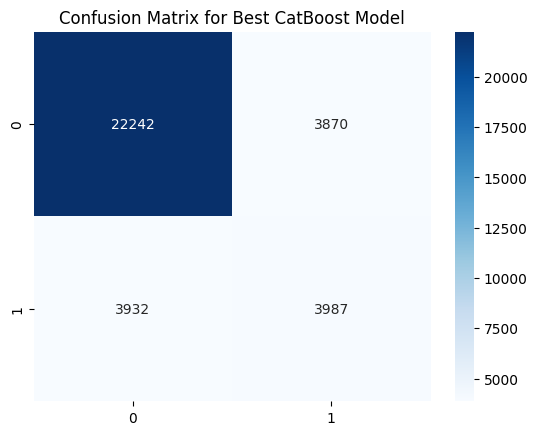

In [132]:
sns.heatmap(cb_conf_mat, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Best CatBoost Model')

## Build LightGBM Model


In [135]:
#Define hyperparameter space
lgbm_param_dists = {
    'num_leaves':randint(31,255),
    'max_depth':randint(2,15),
    'learning_rate':uniform(0.01,0.3),
    'n_estimators':randint(100,900),
    'min_child_samples':randint(10,100),
    'subsample':uniform(0.6,0.4),
    'colsample_bytree':uniform(0.6,0.4)
}

#Define estimator
lgbm_model = LGBMClassifier(
    boosting_type='gbdt',
    objective='binary',
    is_unbalance=False,
    verbose=-1,
)

#Define random search
lgbm_random_search = RandomizedSearchCV(
    estimator=lgbm_model,
    param_distributions=lgbm_param_dists,
    n_iter=50,
    scoring='recall',
    cv=5,
    verbose=2,
    n_jobs=-1
)

In [136]:
#Fit model
lgbm_random_search.fit(X_resample, y_resample)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END colsample_bytree=0.8008911686153377, learning_rate=0.08181160163556934, max_depth=7, min_child_samples=49, n_estimators=568, num_leaves=76, subsample=0.8379482384327559; total time=  31.8s
[CV] END colsample_bytree=0.6184581380994466, learning_rate=0.22465535613897966, max_depth=12, min_child_samples=54, n_estimators=739, num_leaves=155, subsample=0.9229512214859048; total time=  56.0s
[CV] END colsample_bytree=0.6184581380994466, learning_rate=0.22465535613897966, max_depth=12, min_child_samples=54, n_estimators=739, num_leaves=155, subsample=0.9229512214859048; total time= 1.0min
[CV] END colsample_bytree=0.9907736918931239, learning_rate=0.13268059580191457, max_depth=7, min_child_samples=82, n_estimators=125, num_leaves=194, subsample=0.7990301189708103; total time=  29.3s
[CV] END colsample_bytree=0.9907736918931239, learning_rate=0.13268059580191457, max_depth=7, min_child_samples=82, n_estimators=125, num_lea

RandomizedSearchCV(cv=5,
                   estimator=LGBMClassifier(is_unbalance=False,
                                            objective='binary', verbose=-1),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'colsample_bytree': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7d63aef59c10>,
                                        'learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7d642b1088d0>,
                                        'max_depth': <scip...
                                        'min_child_samples': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7d63f5191790>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7d63aef66390>,
                                        'num_leaves': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7d63f51b85d0>,
                                        'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7d645e8f8e10>},
                   scoring='recall', verbose=2)

In [137]:
#Get best model
lgbm_best_model = lgbm_random_search.best_estimator_

#Make predictions and get probabilities
y_pred_lgbm = lgbm_best_model.predict(X_test)
y_probs_lgbm = lgbm_best_model.predict_proba(X_test)[:,1]

In [142]:
#Get metrics
lgbm_conf_mat = confusion_matrix(y_test,y_pred_lgbm)
report_lgbm = classification_report(y_test, y_pred_lgbm, output_dict=True)

#Get importances
importances_lgbm = pd.Series(lgbm_best_model.feature_importances_, index=X_resample.columns)
importances_lgbm.sort_values(ascending=False).to_csv('importances_lgbm.csv')

#Save model
joblib.dump(lgbm_best_model,'/kaggle/working/lgbm_model.pkl')

#Save predictions
lgbm_pred_df = pd.DataFrame({
    'True':y_test,
    'Predicted':y_pred_lgbm,
    'Predicted Probability':y_probs_lgbm,
})
lgbm_pred_df.to_csv('/kaggle/working/predictions_lgbm.csv')

#Save report
pd.DataFrame(report_lgbm).to_csv('/kaggle/working/report_lgbm.csv')

In [139]:
print(classification_report(y_test,y_pred_lgbm))

              precision    recall  f1-score   support

           0       0.85      0.78      0.81     26112
           1       0.43      0.53      0.47      7919

    accuracy                           0.72     34031
   macro avg       0.64      0.66      0.64     34031
weighted avg       0.75      0.72      0.73     34031



Text(0.5, 1.0, 'Confusion Matrix for Best LightGBM Model')

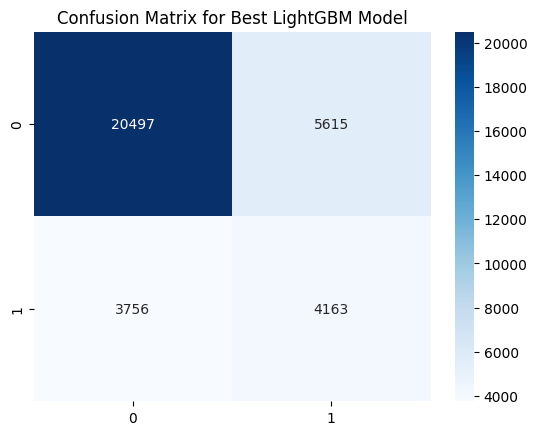

In [140]:
sns.heatmap(lgbm_conf_mat, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Best LightGBM Model')

# K-Nearest Neighbors

In [143]:
#Define pipeline to scale and run knn
knn_pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('knn',KNeighborsClassifier())
])

#Define hyperparameters
knn_params = {
    'knn__n_neighbors':range(3,21),
    'knn__weights':['uniform','distance'],
    'knn__p':[1,2]
}

#Define gridsearch function
knn_grid_search = GridSearchCV(
    knn_pipeline,
    param_grid=knn_params,
    scoring='recall',
    cv=5,
    n_jobs=-1,
    verbose=2,
)

In [145]:
#Fit models
knn_grid_search.fit(X_resample,y_resample)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('knn', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'knn__n_neighbors': range(3, 21), 'knn__p': [1, 2],
                         'knn__weights': ['uniform', 'distance']},
             scoring='recall', verbose=2)

In [146]:
#Get best model
knn_best_model = knn_grid_search.best_estimator_

#Make predictions, get probabilities
y_pred_knn = knn_best_model.predict(X_test)
y_probs_knn = knn_best_model.predict_proba(X_test)[:,1]

In [148]:
#Get metrics
knn_conf_mat = confusion_matrix(y_test, y_pred_knn)
report_knn = classification_report(y_test, y_pred_knn, output_dict=True)

#Save model
joblib.dump(knn_best_model,'/kaggle/working/knn_model.pkl')

#Save predictions
knn_pred_df = pd.DataFrame({
    'True':y_test,
    'Predicted':y_pred_knn,
    'Predicted Probability':y_probs_knn,
})
knn_pred_df.to_csv('/kaggle/working/predictions_knn.csv')

#Save report
pd.DataFrame(report_knn).to_csv('/kaggle/working/report_knn.csv')

In [149]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.84      0.70      0.76     26112
           1       0.36      0.55      0.44      7919

    accuracy                           0.67     34031
   macro avg       0.60      0.63      0.60     34031
weighted avg       0.73      0.67      0.69     34031



Text(0.5, 1.0, 'Confusion Matrix for Best K-Nearest Neighbors Model')

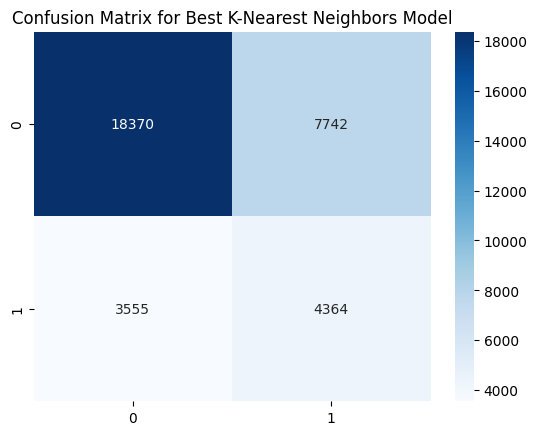

In [150]:
sns.heatmap(knn_conf_mat, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Best K-Nearest Neighbors Model')

# Tree Models

## Random Forest Model

In [1]:
#Define hyperparameter space
rf_params = {
    'n_estimators':randint(100,500),
    'max_depth':randint(3,20),
    'min_samples_split':randint(2,10),
    'min_samples_leaf':randint(1,10),
    'max_features':['auto','sqrt','log2'],
    'bootstrap':[True, False]
}

#Define estimator
rf_model = RandomForestClassifier()

#Define random search
rf_random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=rf_params,
    n_iter=25,
    cv=5,
    verbose=2,
    scoring='recall',
    n_jobs=-1,
)


NameError: name 'randint' is not defined

In [ ]:
#Fit models
rf_random_search.fit(X_resample,y_resample)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomFor

In [ ]:
#Get best model and parameters
rf_best_model = rf_random_search.best_estimator_
rf_best_params = rf_random_search.best_params

#Get predictions
y_pred_rf = rf_best_model.predict(X_test)
y_probs_rf = rf_best_model.predict_proba(X_test)[:,1]

In [ ]:
#Get metrics
rf_report = classification_report(y_test,y_pred_rf)
rf_conf_mat = confusion_matrix(y_test,y_pred_rf)

#Save model
joblib.dump(rf_best_model,'/kaggle/working/rf_model.pkl')

#Save predictions
rf_pred_df = pd.DataFrame({
    'True':y_test,
    'Predicted':y_pred_rf,
    'Predicted Probability':y_probs_rf,
})
rf_pred_df.to_csv('/kaggle/working/predictions_rf.csv')

#Save report
pd.DataFrame(report_rf).to_csv('/kaggle/working/report_rf.csv')

with open('/kaggle/working/rf_best_params.json','w') as f:
    json.dump(rf_best_params, f, indent=4)

In [ ]:
print(classification_report(y_test, y_pred_rf))

In [ ]:
sns.heatmap(rf_conf_mat, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Best Random Forest Model')

## Extra Trees

In [ ]:
#Define hyperparameter space
et_params = {
    'n_estimators':randint(100,500),
    'max_depth':randint(3,20),
    'min_samples_split':randint(2,10),
    'min_samples_leaf':randint(1,10),
    'max_features':['auto','sqrt','log2'],
    'bootstrap':[True, False],
}

#Define estimator
et_model = ExtraTreesClassifier()

#Define random search
et_random_search = RandomizedSearchCV(
    estimator=et_model,
    param_distributions=et_params,
    n_iter=25,
    cv=5,
    scoring='recall',
    verbose=2,
    n_jobs=-1,
)

In [ ]:
#Fit model
et_random_search.fit(X_resample, y_resample)

In [ ]:
#Get best model and parameters
et_best_model = et_random_search.best_estimator_
et_best_params = et_random_search.best_params

#Get predictions
y_pred_et = et_best_model.predict(X_test)
y_probs_et = et_best_model.predict_proba(X_test)[:,1]

In [ ]:
#Get metrics
report_et = classification_report(y_test,y_pred_et)
et_conf_mat = confusion_matrix(y_test,y_pred_et)

#Save model
joblib.dump(et_best_model,'/kaggle/working/et_model.pkl')

#Save predictions
et_pred_df = pd.DataFrame({
    'True':y_test,
    'Predicted':y_pred_et,
    'Predicted Probability':y_probs_et,
})
et_pred_df.to_csv('/kaggle/working/predictions_et.csv')

#Save report
pd.DataFrame(report_et).to_csv('/kaggle/working/report_et.csv')

with open('/kaggle/working/et_best_params.json','w') as f:
    json.dump(et_best_params, f, indent=4)

In [ ]:
print(classification_report(y_test, y_pred_et))

In [ ]:
sns.heatmap(et_conf_mat, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Best Extra Trees Model')

# Tabular Neural Network

### (A Convolutional Neural Network for Tabular Data based on TabNet Architecture)

In [5]:
def build_tnn_model(input_shape, dropout_rate, hidden_units):
    
    input_layer = Input(shape=(input_shape,))
    x = Lambda(lambda x:tf.expand_dims(x, axis=-1))(input_layer)
    
    x = Conv1D(kernel_size=3, filters=32, activation='relu')(x)
    x = AveragePooling1D(pool_size=2)(x)
    
    x = Conv1D(kernel_size=3, filters=32, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    
    skip=x
    
    x = Conv1D(kernel_size=3, filters=32, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    
    x = Conv1D(kernel_size=3, filters=32, activation='relu', padding='same')(x)
    x = Add()([x,skip])
    
    x = MaxPooling1D(pool_size=2)(x)
    x = Flatten()(x)
    x = Dropout(dropout_rate)(x)
    x = Dense(64, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)
    x = Dense(hidden_units, activation='relu')(x)
    
    output_layer = Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs=input_layer,outputs=output_layer)
    model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
    
    return model

In [6]:
#Build model
tnn_model = KerasClassifier(model=build_tnn_model, input_shape=X_resample.shape[1], verbose=0)

#Define hyperparameter space
tnn_params = {
    'model__dropout_rate':uniform(0.2,0.5),
    'model__hidden_units':randint(16,128),
    'batch_size':[16,32,64],
    'epochs':[20,40,60],
}

#Define Random Search
tnn_random_search = RandomizedSearchCV(
    estimator=tnn_model,
    param_distributions=tnn_params,
    n_iter=10,
    cv=5,
    verbose=2,
    scoring='recall'
)

In [11]:
tnn_random_search.fit(X_resample, y_resample)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END batch_size=16, epochs=20, model__dropout_rate=0.699345606809531, model__hidden_units=109; total time=11.1min
[CV] END batch_size=16, epochs=20, model__dropout_rate=0.699345606809531, model__hidden_units=109; total time=11.2min
[CV] END batch_size=16, epochs=20, model__dropout_rate=0.699345606809531, model__hidden_units=109; total time=11.2min
[CV] END batch_size=16, epochs=20, model__dropout_rate=0.699345606809531, model__hidden_units=109; total time=11.4min
[CV] END batch_size=16, epochs=20, model__dropout_rate=0.699345606809531, model__hidden_units=109; total time=11.1min
[CV] END batch_size=16, epochs=60, model__dropout_rate=0.40869991439343767, model__hidden_units=20; total time=31.4min
[CV] END batch_size=16, epochs=60, model__dropout_rate=0.40869991439343767, model__hidden_units=20; total time=31.4min
[CV] END batch_size=16, epochs=60, model__dropout_rate=0.40869991439343767, model__hidden_units=20; total time=

RandomizedSearchCV(cv=5,
                   estimator=KerasClassifier(input_shape=10, model=<function build_tnn_model at 0x78c292f11bc0>, verbose=0),
                   param_distributions={'batch_size': [16, 32, 64],
                                        'epochs': [20, 40, 60],
                                        'model__dropout_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x78c34def6510>,
                                        'model__hidden_units': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x78c29bf7aed0>},
                   scoring='recall', verbose=2)

In [12]:
tnn_best_model = tnn_random_search.best_estimator_
y_pred_tnn = tnn_best_model.predict(X_test)
y_probs_tnn = tnn_best_model.predict_proba(X_test)[:,1]

In [13]:
#Get metrics
tnn_conf_mat = confusion_matrix(y_test, y_pred_tnn)
report_tnn = classification_report(y_test, y_pred_tnn, output_dict=True)

#Save model
joblib.dump(tnn_best_model,'/kaggle/working/tnn_model.pkl')

#Save predictions
tnn_pred_df = pd.DataFrame({
    'True':y_test,
    'Predicted':y_pred_tnn,
    'Predicted Probability':y_probs_tnn,
})
tnn_pred_df.to_csv('/kaggle/working/predictions_tnn.csv')

#Save report
pd.DataFrame(report_tnn).to_csv('/kaggle/working/report_tnn.csv')

In [14]:
print(classification_report(y_test, y_pred_tnn))

              precision    recall  f1-score   support

           0       0.85      0.90      0.88     26112
           1       0.60      0.47      0.53      7919

    accuracy                           0.80     34031
   macro avg       0.72      0.69      0.70     34031
weighted avg       0.79      0.80      0.79     34031



Text(0.5, 1.0, 'Confusion Matrix for Best Tabular Neural Network Model')

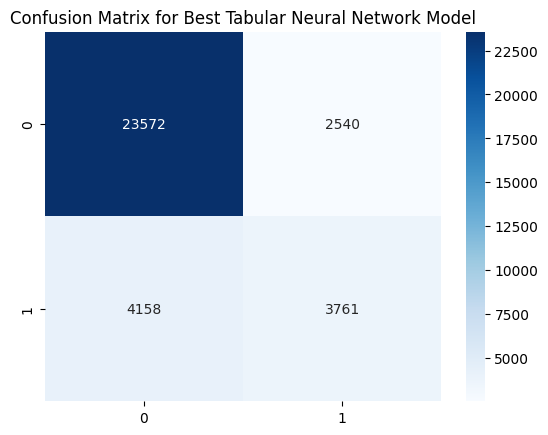

In [15]:
sns.heatmap(tnn_conf_mat, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Best Tabular Neural Network Model')